<div align="center">

# Data Projects and Hackathon 3  
## Project 
Sergio Fernandez, Alessandro Mecchia 

</div>

In [5]:
# Standard Library
import gc
import json
import math
import os
import re
import subprocess
import sys
import time
import unicodedata
import warnings
from collections import defaultdict
from pathlib import Path

# Data Processing & Math
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.json as paj
import pyarrow.parquet as pq
import duckdb

# GPU Acceleration (RAPIDS)
import cudf
import cugraph

# Machine Learning & NLP
import lightgbm as lgb
import torch
import yake
from langdetect import DetectorFactory, detect
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, pipeline

from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go


# Interactive Notebook Tools
import ipywidgets as widgets
from IPython.display import display

# HTTP / Networking
import requests

# Configuration

warnings.filterwarnings("ignore")
DetectorFactory.seed = 0  # Ensure consistent language detection

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cuda


In [3]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)


## Functions 

In [6]:
def to_python_nested(x):
    if x is None:
        return None
    if isinstance(x, float) and pd.isna(x):
        return None
    if isinstance(x, np.ndarray):
        return [to_python_nested(v) for v in x.tolist()]
    if isinstance(x, tuple):
        return [to_python_nested(v) for v in x]
    if isinstance(x, list):
        return [to_python_nested(v) for v in x]
    if isinstance(x, dict):
        return {k: to_python_nested(v) for k, v in x.items()}
    return x

def normalize_author_value(v):
    if isinstance(v, np.generic):
        v = v.item()
    if isinstance(v, float) and pd.isna(v):
        return None
    return v

def normalize_authors_cell(x):
    if x is None:
        return None
    if isinstance(x, float) and pd.isna(x):
        return None

    if isinstance(x, np.ndarray):
        x = x.tolist()
    elif isinstance(x, dict):
        x = [x]
    elif isinstance(x, tuple):
        x = list(x)
    elif not isinstance(x, list):
        return None

    out = []
    for item in x:
        if isinstance(item, np.ndarray):
            item = item.tolist()

        if not isinstance(item, dict):
            continue

        clean_item = {k: normalize_author_value(v) for k, v in item.items()}
        out.append(clean_item)

    return out if out else None

def is_empty(x):
    if x is None:
        return True
    if isinstance(x, str):
        return x.strip() == ""
    if isinstance(x, (list, tuple, set, dict)):
        return len(x) == 0
    if isinstance(x, np.ndarray):
        return x.size == 0
    return pd.isna(x)

def valid_authors_sequence(authors):
    if authors is None:
        return False
    if isinstance(authors, float) and pd.isna(authors):
        return False
    try:
        if isinstance(authors, np.ndarray):
            return authors.ndim > 0 and len(authors) > 0
        return isinstance(authors, (list, tuple)) and len(authors) > 0
    except Exception:
        return False
    
def authors_complete(authors):
    if not valid_authors_sequence(authors):
        return False

    for author in authors:
        if not isinstance(author, dict):
            return False
        if is_empty(author.get("id")) or is_empty(author.get("org")):
            return False

    return True

In [5]:
def check_missing_column(pf, col):
    missing_count = 0
    filled_count = 0
    n = 0

    for rg in range(pf.num_row_groups):
        chunk = pf.read_row_group(rg, columns=[col]).to_pandas()
        missing_mask = chunk[col].apply(is_empty)

        missing_count += missing_mask.sum()
        filled_count += (~missing_mask).sum()
        n += len(chunk)

    print(f"{col} summary (sample of {n:,} rows):\n")
    print(f"missing : {missing_count:,}")
    print(f"filled  : {filled_count:,}")
    print(f"missing %: {missing_count / n * 100:.4f}")

In [6]:
from concurrent.futures import ThreadPoolExecutor, as_completed

OPENALEX_REFERENCES_CACHE = Path("data/cache_openalex_references.json")
MAILTO = ""  # put your email here for polite pool

def load_cache(path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def save_cache(path, cache):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(cache, f, ensure_ascii=False)

def normalize_doi(x):
    if x is None:
        return ""
    x = str(x).strip().lower()
    return x.replace("https://doi.org/", "").replace("http://doi.org/", "").rstrip("/")

def chunked(seq, size):
    for i in range(0, len(seq), size):
        yield seq[i:i + size]

def fetch_openalex_references_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,referenced_works",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        refs = work.get("referenced_works", [])
        out[doi] = refs if refs else None
    return out

def fetch_openalex_references_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_references_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_references_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_REFERENCES_CACHE)

    mask = df["references"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"references: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"references: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_references_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_REFERENCES_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        refs = cache.get(doi)

        if refs and is_empty(df.at[idx, "references"]):
            df.at[idx, "references"] = refs
            recovered += 1

    print("\nImputation completed for references")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['references'].apply(is_empty).sum()}")

In [7]:
OPENALEX_ABSTRACT_CACHE = Path("data/cache_openalex_abstracts.json")
MAILTO = "" # put your email here for polite pool

def reconstruct_abstract(inverted_index):
    if not inverted_index:
        return None

    max_pos = max((max(pos) for pos in inverted_index.values() if pos), default=-1)
    if max_pos < 0:
        return None

    words = [""] * (max_pos + 1)
    for word, positions in inverted_index.items():
        for pos in positions:
            words[pos] = word

    text = " ".join(words).strip()
    return text if text else None

def fetch_openalex_abstracts_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,abstract_inverted_index",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        abstract = reconstruct_abstract(work.get("abstract_inverted_index"))
        out[doi] = abstract
    return out

def fetch_openalex_abstracts_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_abstracts_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_abstract_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_ABSTRACT_CACHE)

    mask = df["abstract"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"abstract: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"abstract: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_abstracts_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_ABSTRACT_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        abstract = cache.get(doi)

        if abstract and is_empty(df.at[idx, "abstract"]):
            df.at[idx, "abstract"] = abstract
            recovered += 1

    print("\nImputation completed for abstract")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['abstract'].apply(is_empty).sum()}")


In [8]:
OPENALEX_VENUE_CACHE = Path("data/cache_openalex_venue.json")
MAILTO = "" # put your email here for polite pool

def extract_venue_from_work(data):
    if not isinstance(data, dict):
        return None
    venue = data.get("primary_location", {}).get("raw_source_name")
    return venue if venue else None

def fetch_openalex_venue_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,primary_location",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        venue = extract_venue_from_work(work)
        out[doi] = venue
    return out

def fetch_openalex_venue_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_venue_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_venue_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_VENUE_CACHE)

    mask = df["venue"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"venue: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"venue: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_venue_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_VENUE_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        venue = cache.get(doi)

        if venue and is_empty(df.at[idx, "venue"]):
            df.at[idx, "venue"] = venue
            recovered += 1

    print("\nImputation completed for venue")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['venue'].apply(is_empty).sum()}")


In [12]:
OPENALEX_KEYWORDS_CACHE = Path("data/cache_openalex_keywords.json")
MAILTO = "" # put your email here for polite pool

def extract_keywords_from_work(data):
    if not isinstance(data, dict):
        return None

    concepts = data.get("concepts", [])
    keywords = [
        c["display_name"]
        for c in concepts
        if c.get("level", 0) >= 1 and c.get("score", 0) >= 0.3
    ]
    return keywords if keywords else None

def fetch_openalex_keywords_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,concepts",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        keywords = extract_keywords_from_work(work)
        out[doi] = keywords
    return out

def fetch_openalex_keywords_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_keywords_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_keywords_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_KEYWORDS_CACHE)

    mask = df["keywords"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"keywords: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"keywords: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_keywords_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_KEYWORDS_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        keywords = cache.get(doi)

        if keywords and is_empty(df.at[idx, "keywords"]):
            df.at[idx, "keywords"] = keywords
            recovered += 1

    print("\nImputation completed for keywords")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['keywords'].apply(is_empty).sum()}")


In [13]:
OPENALEX_DOC_TYPE_CACHE = Path("data/cache_openalex_doc_type.json")

def fetch_openalex_doc_type_batch(dois_batch, timeout=30):
    session = requests.Session()
    doi_filter = "|".join(dois_batch)

    r = session.get(
        "https://api.openalex.org/works",
        params={
            "filter": f"doi:{doi_filter}",
            "select": "doi,type",
            "per_page": len(dois_batch),
            "mailto": MAILTO,
        },
        headers={"User-Agent": "DBLP-imputation/1.0"},
        timeout=timeout,
    )
    r.raise_for_status()

    out = {}
    for work in r.json().get("results", []):
        doi = normalize_doi(work.get("doi"))
        doc_type = work.get("type")
        out[doi] = doc_type if doc_type else None
    return out

def fetch_openalex_doc_type_parallel(dois, batch_size=50, max_workers=4, pause_s=0.05):
    results = {}
    batches = list(chunked(dois, batch_size))

    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(fetch_openalex_doc_type_batch, batch): batch
            for batch in batches
        }

        for i, fut in enumerate(as_completed(futures), start=1):
            batch = futures[fut]
            try:
                batch_result = fut.result()
                results.update(batch_result)
            except Exception as e:
                print(f"Batch failed ({len(batch)} dois): {e}")

            if i % 10 == 0 or i == len(batches):
                print(f"  batches completed: {i}/{len(batches)}")
                if pause_s > 0:
                    time.sleep(pause_s)

    return results

def impute_doc_type_from_openalex_batch(df, batch_size=50, max_workers=4):
    cache = load_cache(OPENALEX_DOC_TYPE_CACHE)

    mask = df["doc_type"].apply(is_empty) & ~df["doi"].apply(is_empty)
    target_idx = df[mask].index.tolist()
    print(f"doc_type: rows to inspect = {len(target_idx)}")

    dois = [normalize_doi(df.at[idx, "doi"]) for idx in target_idx]
    dois = [d for d in dois if d]

    unique_missing = sorted({d for d in dois if d not in cache})
    print(f"doc_type: DOI not in cache = {len(unique_missing)}")

    if unique_missing:
        fetched = fetch_openalex_doc_type_parallel(
            unique_missing,
            batch_size=batch_size,
            max_workers=max_workers,
        )
        cache.update(fetched)
        save_cache(OPENALEX_DOC_TYPE_CACHE, cache)

    recovered = 0
    for idx in target_idx:
        doi = normalize_doi(df.at[idx, "doi"])
        doc_type = cache.get(doi)

        if doc_type and is_empty(df.at[idx, "doc_type"]):
            df.at[idx, "doc_type"] = doc_type
            recovered += 1

    print("\nImputation completed for doc_type")
    print(f"Recovered: {recovered}/{len(target_idx)}")
    print(f"Still missing: {df['doc_type'].apply(is_empty).sum()}")


In [14]:
from collections import defaultdict
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 0

SUPPORTED_LANGS = {"en", "de", "fr", "pt", "es", "it", "zh", "ja", "ko", "ru"}

YAKE_LANG_MAP = {
    "en": "en",
    "it": "it",
    "fr": "fr",
    "de": "de",
    "es": "es",
    "pt": "pt",
    "zh": "zh",
    "ja": "ja",
    "ko": "ko",
    "ru": "ru",
}


In [15]:
def detect_lang(row):
    parts = []
    for col in ["title", "abstract", "venue"]:
        val = row.get(col)
        if isinstance(val, str) and val.strip():
            parts.append(val.strip())

    text = " ".join(parts)

    if len(text) < 30:
        return None

    try:
        pred = detect(text)
        return pred if pred in SUPPORTED_LANGS else None
    except Exception:
        return None


In [16]:
def valid_authors_sequence(authors):
    if authors is None:
        return False
    if isinstance(authors, float) and pd.isna(authors):
        return False

    try:
        if isinstance(authors, np.ndarray):
            return authors.ndim > 0 and len(authors) > 0
        return isinstance(authors, (list, tuple)) and len(authors) > 0
    except Exception:
        return False


def build_author_mappings(input_path):
    pf = pq.ParquetFile(input_path)

    name_to_id = {}
    name_to_year_orgs = defaultdict(list)

    for rg in range(pf.num_row_groups):
        print(f"[authors mapping] Row group {rg + 1}/{pf.num_row_groups}")

        chunk = pf.read_row_group(rg, columns=["authors", "year"]).to_pandas()

        for _, row in chunk.iterrows():
            year = row.get("year")
            authors = row.get("authors")

            if not valid_authors_sequence(authors):
                continue

            parsed_year = None
            try:
                if year is not None and not (isinstance(year, float) and pd.isna(year)):
                    parsed_year = int(year)
            except Exception:
                parsed_year = None

            for author in authors:
                if not isinstance(author, dict):
                    continue

                name = author.get("name")
                author_id = author.get("id")
                org = author.get("org")

                if isinstance(name, str):
                    name = name.strip()

                if not name:
                    continue

                if isinstance(author_id, str) and author_id.strip() and name not in name_to_id:
                    name_to_id[name] = author_id.strip()

                if isinstance(org, str) and org.strip() and parsed_year is not None:
                    name_to_year_orgs[name].append((parsed_year, org.strip()))

    print(f"Created mapping for {len(name_to_id):,} unique author names")
    print(f"Created org history for {len(name_to_year_orgs):,} author names")

    return name_to_id, name_to_year_orgs


In [17]:
def impute_authors_id_chunk(chunk, name_to_id):
    recovered = 0

    for idx, row in chunk.iterrows():
        authors = row.get("authors")

        if not valid_authors_sequence(authors):
            continue

        changed = False
        for author in authors:
            if not isinstance(author, dict):
                continue

            name = author.get("name")
            author_id = author.get("id")

            if isinstance(name, str):
                name = name.strip()

            if not author_id and name and name in name_to_id:
                author["id"] = name_to_id[name]
                recovered += 1
                changed = True

        if changed:
            chunk.at[idx, "authors"] = authors

    print(f"Recovered {recovered:,} author IDs")
    return chunk


In [18]:
def impute_authors_org_chunk(chunk, name_to_year_orgs, max_year_diff=1):
    recovered = 0

    for idx, row in chunk.iterrows():
        year = row.get("year")
        authors = row.get("authors")

        if not valid_authors_sequence(authors):
            continue

        try:
            if year is None or (isinstance(year, float) and pd.isna(year)):
                continue
            year = int(year)
        except Exception:
            continue

        changed = False
        for author in authors:
            if not isinstance(author, dict):
                continue

            name = author.get("name")
            org = author.get("org")

            if isinstance(name, str):
                name = name.strip()

            if org or not name:
                continue

            candidates = name_to_year_orgs.get(name)
            if not candidates:
                continue

            best_org = None
            best_distance = float("inf")

            for cand_year, cand_org in candidates:
                distance = abs(cand_year - year)
                if distance <= max_year_diff and distance < best_distance:
                    best_org = cand_org
                    best_distance = distance
                    if distance == 0:
                        break

            if best_org:
                author["org"] = best_org
                recovered += 1
                changed = True

        if changed:
            chunk.at[idx, "authors"] = authors

    print(f"Recovered {recovered:,} author ORGs")
    return chunk


## 1. Data Creation

The raw dataset is DBLP Citation Network V18, a large JSONL file containing millions of scientific papers. Loading it directly into memory is not feasible, so we first convert it to Parquet a compressed columnar format that allows efficient on-disk querying and then query it with DuckDB without ever loading the full dataset into RAM.

###  1.2. Parquet Creation 

Run only once. We stream the JSONL file batch by batch and write it incrementally to a compressed Parquet file, dropping a few uninformative columns along the way.

In [25]:
DATA_DIR = Path("data")
SOURCE_PATH = DATA_DIR / "DBLP-Citation-network-V18.jsonl"
TARGET_PATH = DATA_DIR / "DBLP-Citation-network-V18.parquet"
BLOCK_SIZE = 64 * 1024 * 1024  

if TARGET_PATH.exists() or Path("final_dataset.parquet").exists() or Path("dataset.parquet").exists():
    raise FileNotFoundError(f"File non trovato: {SOURCE_PATH}")

if pa.Codec.is_available("zstd"):
    COMPRESSION = "zstd"
elif pa.Codec.is_available("snappy"):
    COMPRESSION = "snappy"
else:
    COMPRESSION = None

if SOURCE_PATH.exists():
    print(f"Input : {SOURCE_PATH} ({SOURCE_PATH.stat().st_size / 1024**3:.2f} GiB)")
else:
    print(f"Input : {SOURCE_PATH} (missing)")

print(f"Output: {TARGET_PATH}")
print(f"Compression: {COMPRESSION}")
print(f"Block size: {BLOCK_SIZE / 1024**2:.0f} MiB")

Input : data/DBLP-Citation-network-V18.jsonl (missing)
Output: data/DBLP-Citation-network-V18.parquet
Compression: zstd
Block size: 64 MiB


In [28]:
DROP_COLS = {"page_start", "page_end", "volume", "issue", "issn", "isbn", "url"}

if TARGET_PATH.exists():
    print(f"Parquet already exists, skipping conversion.")
else:
    reader = paj.open_json(
        SOURCE_PATH,
        read_options=paj.ReadOptions(block_size=BLOCK_SIZE),
    )

    writer = None
    rows_written = 0
    batches_written = 0
    started_at = time.perf_counter()

    try:
        while True:
            try:
                batch = reader.read_next_batch()
            except StopIteration:
                break

            keep_cols = [name for name in batch.schema.names if name not in DROP_COLS]
            batch = batch.select(keep_cols)

            if writer is None:
                writer = pq.ParquetWriter(
                    TARGET_PATH,
                    batch.schema,
                    compression=COMPRESSION,
                )

            writer.write_batch(batch)
            rows_written += batch.num_rows
            batches_written += 1

            if batches_written % 25 == 0:
                elapsed = time.perf_counter() - started_at
                print(f"Batch: {batches_written:>5} | Rows: {rows_written:>12,} | Elapsed: {elapsed:>8.1f}s")

        if writer is None:
            raise RuntimeError("JSONL file seems empty: no batch read.")
    finally:
        reader.close()
        if writer is not None:
            writer.close()

    elapsed = time.perf_counter() - started_at
    print(f"Conversion completed in {elapsed:.1f}s")
    print(f"Rows written : {rows_written:,}")
    print(f"JSONL size   : {SOURCE_PATH.stat().st_size / 1024**3:.2f} GiB")
    print(f"Parquet size : {TARGET_PATH.stat().st_size / 1024**3:.2f} GiB")

FileNotFoundError: [Errno 2] Failed to open local file 'data/DBLP-Citation-network-V18.jsonl'. Detail: [errno 2] No such file or directory

### 1.3 Data Creation with DuckDB

We run all profiling and data quality checks directly on the full Parquet file via DuckDB, so that missing value counts and year distributions reflect the entire dataset rather than a sample.

In [ ]:
PARQUET_PATH = Path("data/DBLP-Citation-network-V18.parquet")


con = duckdb.connect(":memory:")

# con = duckdb.connect(r"C:\Users\ms\Desktop\dblp.duckdb")

con.execute("PRAGMA threads=4;")
con.execute("PRAGMA enable_progress_bar;")

parquet_str = PARQUET_PATH.as_posix()

con.execute(f"""
    CREATE OR REPLACE VIEW papers AS
    SELECT *
    FROM read_parquet('{parquet_str}');
""")

In [ ]:
display(con.execute("SELECT * FROM papers LIMIT 5").fetchdf())

In [ ]:
# PROFILE_DB_PATH = DATA_DIR / "dblp_profiling.duckdb"

# con_full = duckdb.connect(PROFILE_DB_PATH.as_posix())
# con_full.execute("PRAGMA threads=4;")
# con_full.execute("PRAGMA enable_progress_bar;")

# con_full.execute(f"""
#     CREATE OR REPLACE VIEW papers_full AS
#     SELECT *
#     FROM read_parquet('{parquet_str}');
# """)

# total_rows_full = con_full.execute("SELECT COUNT(*) FROM papers_full").fetchone()[0]
# print(f"Profiling DB: {PROFILE_DB_PATH}")
# print(f"Total rows available in DuckDB: {total_rows_full:,}")

## 2. Data Exploration  

We start by exploring the dataset to understand its structure, the available fields, and the general quality of the data before any cleaning or filtering.

In [ ]:
# pf = pq.ParquetFile(r"data/DBLP-Citation-network-V18.parquet")

# print(f"Total rows   : {pf.metadata.num_rows:,}")
# print(f"Columns      : {pf.metadata.num_columns}")
# print(f"Row groups   : {pf.metadata.num_row_groups}")

In [ ]:
total_rows = con.execute("""
    SELECT COUNT(*)
    FROM papers
""").fetchone()[0]

n_columns = con.execute("""
    DESCRIBE SELECT * FROM papers
""").fetchdf().shape[0]

row_groups = con.execute(f"""
    SELECT COUNT(DISTINCT row_group_id)
    FROM parquet_metadata('{parquet_str}')
""").fetchone()[0]

print(f"Total rows   : {total_rows:,}")
print(f"Columns      : {n_columns}")
print(f"Row groups   : {row_groups}")


The dataset contains almost 7 million papers across 12 columns. This is relevant because it means we can afford to drop low-quality records without risking significant data loss.

In [ ]:
schema_df = con.execute("""
    DESCRIBE SELECT * FROM papers
""").fetchdf()

for i, name in enumerate(schema_df["column_name"]):
    print(f"{i}. {name}")


In [ ]:
schema_df = con.execute("""
    DESCRIBE SELECT * FROM papers
""").fetchdf()

columns = schema_df["column_name"].tolist()

dropdown = widgets.Dropdown(options=columns, description="Colonna:")
output = widgets.Output()

def on_change(change):
    if change["type"] == "change" and change["name"] == "value":
        col = change["new"]
        with output:
            output.clear_output()
            df = con.execute(f'''
                SELECT "{col}"
                FROM papers
                LIMIT 10
            ''').fetchdf()
            display(df)

dropdown.observe(on_change)

display(dropdown, output)

In [ ]:
paper = con.execute("""
    SELECT *
    FROM papers
    LIMIT 1
""").fetchdf().iloc[0]

for col, val in paper.items():
    print(f"{col:15}: {val}")

We can see the available features and inspect their content. Fields like abstract, keywords, doc_type, venue and references look promising for our task. Columns like page numbers, volume, issue and URLs were already dropped during the Parquet conversion as they carry little predictive meaning for our task.

Interesting is how author data is stored: each paper has an `authors` field containing a list of dictionaries, each with the author's name, id, and affiliated organization.

### 2.1. Data Selection

Since the dataset is large and many papers contain missing values, our goal is to identify and keep only the records with the best data quality. The following charts show how missing values are distributed across features, which will guide our filtering decisions.

In [ ]:
con.execute("""
    CREATE OR REPLACE VIEW papers_profile_base AS
    SELECT
        *,
        CASE WHEN title IS NULL OR TRIM(CAST(title AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_title,
        CASE WHEN abstract IS NULL OR TRIM(CAST(abstract AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_abstract,
        CASE WHEN doi IS NULL OR TRIM(CAST(doi AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_doi,
        CASE WHEN lang IS NULL OR TRIM(CAST(lang AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_lang,
        CASE WHEN venue IS NULL OR TRIM(CAST(venue AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_venue,
        CASE WHEN doc_type IS NULL OR TRIM(CAST(doc_type AS VARCHAR)) = '' THEN TRUE ELSE FALSE END AS flag_missing_doc_type,
        CASE WHEN COALESCE(array_length(keywords), 0) = 0 THEN TRUE ELSE FALSE END AS flag_missing_keywords,
        CASE WHEN COALESCE(array_length("references"), 0) = 0 THEN TRUE ELSE FALSE END AS flag_missing_references,
        CASE WHEN COALESCE(array_length(authors), 0) = 0 THEN TRUE ELSE FALSE END AS flag_missing_authors,
        CASE WHEN TRY_CAST(year AS INTEGER) IS NULL THEN TRUE ELSE FALSE END AS flag_year_missing,
        TRY_CAST(year AS INTEGER) AS year_int

    FROM papers
""")


We create a profiling view that extends the original table with a boolean flag for each column, marking whether the value is missing or empty. This lets us count and filter missing values efficiently using SQL without loading the data into memory.

### 2.1.1. Missing Values

In [ ]:
missing_summary = con.execute("""
    SELECT * FROM (
        SELECT 'title' AS feature, SUM(CAST(flag_missing_title AS INTEGER)) AS count_rows FROM papers_profile_base
        UNION ALL
        SELECT 'abstract', SUM(CAST(flag_missing_abstract AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'doi', SUM(CAST(flag_missing_doi AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'lang', SUM(CAST(flag_missing_lang AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'venue', SUM(CAST(flag_missing_venue AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'doc_type', SUM(CAST(flag_missing_doc_type AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'keywords', SUM(CAST(flag_missing_keywords AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'references', SUM(CAST(flag_missing_references AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'authors', SUM(CAST(flag_missing_authors AS INTEGER)) FROM papers_profile_base
        UNION ALL
        SELECT 'year', SUM(CAST(flag_year_missing AS INTEGER)) FROM papers_profile_base
    )
    ORDER BY count_rows DESC
""").fetchdf()

total_rows = con.execute("SELECT COUNT(*) FROM papers_profile_base").fetchone()[0]
missing_summary["pct_rows"] = missing_summary["count_rows"] / total_rows * 100
missing_summary

In [ ]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=missing_summary, x="feature", y="pct_rows", color="#C44E52", width=0.7)

plt.title("Missing values by feature", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Feature", fontsize=13, fontweight='bold')
plt.ylabel("Missing (%)", fontsize=13, fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, fontsize=11, fontweight='bold')

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()
plt.show()

Looking at the missing values, we can already spot some issues, mainly in keywords, references and doi. Our goal is to work carefully on data quality and retain as much information as possible, dropping only what is truly unrecoverable. This step gives us a clear picture of which columns will require imputation work before we can use them effectively.

In [ ]:
authors_missing_summary = con.execute("""
WITH authors_exploded AS (
    SELECT
        p.id AS paper_id,
        a.author AS author
    FROM papers_profile_base p
    CROSS JOIN UNNEST(p.authors) AS a(author)
)
SELECT
    COUNT(*) AS total_author_rows,
    SUM(CASE WHEN author.id IS NULL OR TRIM(CAST(author.id AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS missing_author_id,
    SUM(CASE WHEN author.name IS NULL OR TRIM(CAST(author.name AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS missing_author_name,
    SUM(CASE WHEN author.org IS NULL OR TRIM(CAST(author.org AS VARCHAR)) = '' THEN 1 ELSE 0 END) AS missing_author_org
FROM authors_exploded
""").fetchdf()

display(authors_missing_summary)

We also inspect missing values inside the `authors` field, which is a nested structure. The main issue is the missing `org` field, while `id` and `name` are mostly present. This is less critical since we can recover missing author information by cross-referencing other papers that share the same author id.

In [ ]:
missing_by_year = con.execute("""
    SELECT
        year_int AS year,
        COUNT(*) AS n_papers,
        SUM(CAST(flag_missing_abstract AS INTEGER)) AS missing_abstract,
        SUM(CAST(flag_missing_doi AS INTEGER)) AS missing_doi,
        SUM(CAST(flag_missing_venue AS INTEGER)) AS missing_venue,
        SUM(CAST(flag_missing_doc_type AS INTEGER)) AS missing_doc_type,
        SUM(CAST(flag_missing_keywords AS INTEGER)) AS missing_keywords,
        SUM(CAST(flag_missing_references AS INTEGER)) AS missing_references
    FROM papers_profile_base
    WHERE year_int IS NOT NULL
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

display(missing_by_year.head(5))

We then look at how missing values are distributed across years. As expected, there are paper with wrong year number and they contain missing values. We decide to restrict the dataset to papers published between 1990 and 2026, since records outside this range are either too sparse or likely erroneous. Additionally, since we plan to use the DOI to recover missing abstracts and references via the OpenAlex API, we drop any paper that is missing its DOI and at the same time has no abstract or no references, as these would be unrecoverable.

In [ ]:
con.execute("""
CREATE OR REPLACE VIEW papers_scope AS
SELECT *
FROM papers_profile_base
WHERE year_int > 1990
  AND year_int < 2027
  AND NOT (
      flag_missing_doi
      AND (flag_missing_abstract OR flag_missing_references)
  )
""")

We count the total number of missing values per paper to understand how quality is distributed across the dataset. This will help us decide a clean threshold for filtering.

In [ ]:
missing_counts_query = con.execute("""
WITH missing_per_paper AS (
    SELECT
        id,
        CAST(flag_missing_title AS INTEGER) +
        CAST(flag_missing_abstract AS INTEGER) +
        CAST(flag_missing_doi AS INTEGER) +
        CAST(flag_missing_lang AS INTEGER) +
        CAST(flag_missing_venue AS INTEGER) +
        CAST(flag_missing_doc_type AS INTEGER) +
        CAST(flag_missing_keywords AS INTEGER) +
        CAST(flag_missing_references AS INTEGER) +
        CAST(flag_missing_authors AS INTEGER) +
        CAST(flag_year_missing AS INTEGER) AS num_missing
    FROM papers_scope
)
SELECT
    num_missing,
    COUNT(*) AS count_papers
FROM missing_per_paper
GROUP BY num_missing
ORDER BY num_missing
""").fetchdf()


In [ ]:
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=missing_counts_query, x="num_missing", y="count_papers", color="#C44E52", width=0.7)

plt.title("Distribution of missing values per paper", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Number of missing values", fontsize=13, fontweight='bold')
plt.ylabel("Number of papers", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Fix: use count_papers instead of count_rows
missing_counts_query["pct_papers"] = missing_counts_query["count_papers"] / missing_counts_query["count_papers"].sum() * 100

As we can see, the majority of papers have 0 or 1 missing value, totaling over 4 million records. Since papers with 2 or more missing values represent a small minority, we drop them to save space and reduce computation time, while still retaining most of the dataset.

In [ ]:
con.execute("""
CREATE OR REPLACE VIEW papers_working AS
SELECT *
FROM (
    SELECT
        *,
        (
            CAST(flag_missing_title AS INTEGER) +
            CAST(flag_missing_abstract AS INTEGER) +
            CAST(flag_missing_lang AS INTEGER) +
            CAST(flag_missing_venue AS INTEGER) +
            CAST(flag_missing_doc_type AS INTEGER) +
            CAST(flag_missing_keywords AS INTEGER) +
            CAST(flag_missing_references AS INTEGER) +
            CAST(flag_missing_authors AS INTEGER) +
            CAST(flag_year_missing AS INTEGER)
        ) AS num_missing
    FROM papers_scope
) t
WHERE num_missing <= 1
""")

In [ ]:
con.execute("""
SELECT
    COUNT(*) AS total_papers,
    SUM(CAST(flag_missing_title AS INTEGER)) AS missing_title,
    SUM(CAST(flag_missing_abstract AS INTEGER)) AS missing_abstract,
    SUM(CAST(flag_missing_doi AS INTEGER)) AS missing_doi,
    SUM(CAST(flag_missing_references AS INTEGER)) AS missing_references,
    SUM(CAST(flag_missing_authors AS INTEGER)) AS missing_authors,
    SUM(CAST(flag_year_missing AS INTEGER)) AS missing_year,
    SUM(CAST(flag_missing_lang AS INTEGER)) AS missing_lang,
    SUM(CAST(flag_missing_venue AS INTEGER)) AS missing_venue,
    SUM(CAST(flag_missing_doc_type AS INTEGER)) AS missing_doc_type
FROM papers_working
""").fetchdf()

In [ ]:
missing_by_year = con.execute("""
    SELECT
        year_int AS year,
        SUM(CAST(flag_missing_abstract AS INTEGER)) AS abstract,
        SUM(CAST(flag_missing_doi AS INTEGER)) AS doi,
        SUM(CAST(flag_missing_venue AS INTEGER)) AS venue,
        SUM(CAST(flag_missing_doc_type AS INTEGER)) AS doc_type,
        SUM(CAST(flag_missing_keywords AS INTEGER)) AS keywords,
        SUM(CAST(flag_missing_references AS INTEGER)) AS "references"
    FROM papers_working
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

missing_by_year = missing_by_year.set_index("year")

missing_by_year.plot(
    kind="bar",
    stacked=True,
    figsize=(16, 7),
    colormap="tab20"
)

plt.title("Missing values by year and feature")
plt.xlabel("Year")
plt.ylabel("Missing count")
plt.tight_layout()
plt.show()

After the initial filtering we are left with about 5.9 million papers. The chart shows that keywords and references are the main sources of remaining missing values, distributed fairly uniformly across years with a natural growth trend. There are no suspicious patterns that would justify excluding any specific time period.

In [ ]:
MAX_OPENALEX_CALLS = 90000

budget_df = con.execute("""
    SELECT
        COUNT(*) FILTER (WHERE flag_missing_abstract) AS n_missing_abstract,
        COUNT(*) FILTER (WHERE flag_missing_references) AS n_missing_references
    FROM papers_working
""").fetchdf()

n_missing_abstract = int(budget_df.loc[0, "n_missing_abstract"])
n_missing_references = int(budget_df.loc[0, "n_missing_references"])
ref_budget = max(0, MAX_OPENALEX_CALLS - n_missing_abstract)

print({
    "missing_abstract_all": n_missing_abstract,
    "missing_references_pool": n_missing_references,
    "reference_sample_budget": ref_budget
})


We compute how many papers are missing an abstract or references, and allocate a call budget for the OpenAlex API. Since the total number of free API calls is capped at 90,000, we first use them to recover missing abstracts, and assign the remaining budget to references. 

In [ ]:
# segment_summary = con.execute(f"""
# SELECT
#     paper_segment,
#     COUNT(*) AS n_papers,
#     SUM(CASE WHEN NOT flag_missing_abstract THEN 1 ELSE 0 END) AS has_abstract,
#     SUM(CASE WHEN NOT flag_missing_references THEN 1 ELSE 0 END) AS has_references,
#     SUM(CASE WHEN NOT flag_missing_doi THEN 1 ELSE 0 END) AS has_doi,
#     SUM(CASE WHEN COALESCE(array_length("references"), 0) >= {MIN_REFERENCES_RECOVERABLE} THEN 1 ELSE 0 END) AS refs_ge_threshold
# FROM papers_record_quality_preimputation
# GROUP BY 1
# """).fetchdf()

Since the reference imputation budget is limited, we distribute the available API calls proportionally across years, so that each year gets a quota proportional to how many papers with missing references it contains.

In [ ]:
ref_year_counts = con.execute("""
    SELECT
        year_int AS year,
        COUNT(*) AS n_year
    FROM papers_working
    WHERE flag_missing_references
      AND NOT flag_missing_abstract
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

if len(ref_year_counts) > 0 and ref_budget > 0:
    ref_year_counts["quota_float"] = (
        ref_year_counts["n_year"] / ref_year_counts["n_year"].sum() * ref_budget
    )
    ref_year_counts["k"] = ref_year_counts["quota_float"].astype(int)

    remaining = ref_budget - int(ref_year_counts["k"].sum())
    if remaining > 0:
        ref_year_counts["frac"] = ref_year_counts["quota_float"] - ref_year_counts["k"]
        extra_idx = ref_year_counts.nlargest(remaining, "frac").index
        ref_year_counts.loc[extra_idx, "k"] += 1
else:
    ref_year_counts["quota_float"] = 0.0
    ref_year_counts["k"] = 0

ref_alloc = ref_year_counts[["year", "k"]].copy()

con.register("ref_alloc_df", ref_alloc)


We then select the final set of paper IDs to work with. Papers that already have references are all kept, while papers with missing references are sampled according to the year quota computed above.

In [ ]:
con.execute("""
CREATE OR REPLACE TABLE papers_final_ids AS
WITH ref_ranked AS (
    SELECT
        p.id,
        p.year_int,
        ROW_NUMBER() OVER (
            PARTITION BY p.year_int
            ORDER BY random()
        ) AS rn
    FROM papers_working p
    WHERE p.flag_missing_references
      AND NOT p.flag_missing_abstract
),
ref_sample AS (
    SELECT r.id
    FROM ref_ranked r
    JOIN ref_alloc_df a
      ON r.year_int = a.year
    WHERE r.rn <= a.k
)
SELECT p.id
FROM papers_working p
LEFT JOIN ref_sample s
  ON p.id = s.id
WHERE
    NOT p.flag_missing_references
    OR s.id IS NOT NULL
""")

In [ ]:
con.execute("""
CREATE OR REPLACE VIEW papers_final_original_filtered AS
SELECT p.*
FROM papers p
JOIN papers_final_ids f
  ON p.id = f.id
""")


We join the selected IDs back to the original papers table and export the final filtered dataset to a new Parquet file, which will be the starting point for the imputation phase.

In [ ]:
output_path = "data/first_dataset.parquet"

if Path(output_path).exists() or Path("data/final_dataset.parquet").exists() or Path("data/dataset.parquet").exists():
    print(f"already exists: {output_path}")
else:
    con.execute(f"""
    COPY papers_final_original_filtered
    TO '{output_path}'
    (FORMAT PARQUET)
    """)

    print("saved:", output_path)

In [ ]:
# pf = pq.ParquetFile(r"data/first_dataset.parquet")

# print(f"Total rows   : {pf.metadata.num_rows:,}")
# print(f"Columns      : {pf.metadata.num_columns}")
# print(f"Row groups   : {pf.metadata.num_row_groups}")

## 3. Dataset Imputation 

At this point we have completed an initial filtering pass, removing papers with poor data quality or too many missing values to be worth recovering. 
For the remaining missing values, we focus only on the features that we believe are relevant for predicting whether a paper cites another.

### 3.1. Abstract, References, Venue and Doc_Type Imputation

Our main imputation strategy relies on OpenAlex, an open bibliographic database that indexes hundreds of millions of scientific works and exposes a free API. Given a paper's DOI, we can query OpenAlex to retrieve missing abstracts, references, venue and doc_type. The process is time-consuming and not always successful, as not every DOI is indexed.

In [ ]:
input_path = "data/first_dataset.parquet"
output_path = "data/middle_dataset.parquet"

if Path(output_path).exists() or Path("data/final_dataset.parquet").exists() or Path("data/dataset.parquet").exists():
    print(f"already exists: {output_path}")
else:
    pf = pq.ParquetFile(input_path)
    writer = None

    try:
        for rg in range(pf.num_row_groups):
            print(f"\n[openalex] Row group {rg + 1}/{pf.num_row_groups}")

            chunk = pf.read_row_group(rg).to_pandas()

            impute_abstract_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            impute_references_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            impute_keywords_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            impute_venue_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            impute_doc_type_from_openalex_batch(
                chunk,
                batch_size=50,
                max_workers=4,
            )

            table = pa.Table.from_pandas(chunk, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(output_path, table.schema)

            writer.write_table(table)

    finally:
        if writer is not None:
            writer.close()

    print(f"saved: {output_path}")

In [ ]:
# clean ram
for var_name in ["pf", "chunk", "table", "writer"]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()

### 3.2. Lang and Authors imputation

For language, we detect it directly from the title and abstract text using a language detection library. For authors, we use a cross-referencing strategy: if an author is missing an id or organization in one paper, we look for the same author name in other papers and borrow the information from there, matching by name and year proximity.

In [ ]:
input_path = "data/middle_dataset.parquet"
output_path = "data/final_dataset.parquet"

if Path(output_path).exists() or Path("data/dataset.parquet").exists():
    print(f"already exists: {output_path}")
else:

    name_to_id, name_to_year_orgs = build_author_mappings(input_path)

    pf = pq.ParquetFile(input_path)
    writer = None

    try:
        for rg in range(pf.num_row_groups):
            print(f"\n[local imputation] Row group {rg + 1}/{pf.num_row_groups}")

            chunk = pf.read_row_group(rg).to_pandas()

            missing_lang_mask = chunk["lang"].apply(is_empty)
            chunk.loc[missing_lang_mask, "lang"] = (
                chunk.loc[missing_lang_mask].apply(detect_lang, axis=1)
            )


            chunk = impute_authors_id_chunk(chunk, name_to_id)
            chunk = impute_authors_org_chunk(chunk, name_to_year_orgs, max_year_diff=1)

            for col in ["authors", "keywords", "references", "url"]:
                if col in chunk.columns:
                    chunk[col] = chunk[col].apply(to_python_nested)

            chunk["authors"] = chunk["authors"].apply(normalize_authors_cell)

            table = pa.Table.from_pandas(chunk, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(output_path, table.schema)

            writer.write_table(table)

    finally:
        if writer is not None:
            writer.close()

    print(f"saved: {output_path}")

In [ ]:
# clean ram
for var_name in ["name_to_id", "name_to_year_orgs", "pf", "chunk", "table", "writer"]:
    if var_name in globals():
        del globals()[var_name]

gc.collect()

### 3.3. Analysis Post imputation

In [ ]:
input_path = "data/final_dataset.parquet"
pf = pq.ParquetFile(input_path)

In [ ]:
from collections import Counter
lang_counter = Counter()
n = 0

for rg in range(pf.num_row_groups):
    chunk = pf.read_row_group(rg, columns=["lang"]).to_pandas()

    for val in chunk["lang"]:
        key = "(null)" if is_empty(val) else val
        lang_counter[key] += 1

    n += len(chunk)

lang_counts = pd.Series(lang_counter).sort_values(ascending=False)

print(f"Unique values of 'lang' (sample of {n:,} rows):\n")
print(lang_counts)

In [ ]:
check_missing_column(pf, "abstract")

In [ ]:
check_missing_column(pf, "references")


In [ ]:
check_missing_column(pf, "keywords")

In [ ]:
check_missing_column(pf, "doc_type")

In [ ]:
check_missing_column(pf, "venue")

In [ ]:
missing_authors_id = 0
missing_authors_org = 0
total_authors = 0
papers_with_no_authors = 0

for rg in range(pf.num_row_groups):
    chunk = pf.read_row_group(rg, columns=["authors"]).to_pandas()

    for authors in chunk["authors"]:
        if not valid_authors_sequence(authors):
            papers_with_no_authors += 1
            continue

        for author in authors:
            if not isinstance(author, dict):
                continue

            total_authors += 1

            if is_empty(author.get("id")):
                missing_authors_id += 1

            if is_empty(author.get("org")):
                missing_authors_org += 1

print(f"Authors summary:\n")
print(f"total authors         : {total_authors:,}")
print(f"missing authors.id    : {missing_authors_id:,}")
print(f"missing authors.org   : {missing_authors_org:,}")
print(f"papers with no authors: {papers_with_no_authors:,}")

if total_authors > 0:
    print(f"missing authors.id %  : {missing_authors_id / total_authors * 100:.4f}")
    print(f"missing authors.org % : {missing_authors_org / total_authors * 100:.4f}")

abbiamo imputato il piu possibile, droppiamo tutti i missing che sono rimasti e lavoriamo con il dataset finale da qui in avanti

In [ ]:
def drop_missing(input_path, output_path, required_cols):
    if Path(output_path).exists():
        print(f"already exists: {output_path}")
        return

    pf = pq.ParquetFile(input_path)
    writer = None
    kept_rows = 0
    dropped_rows = 0

    try:
        for rg in range(pf.num_row_groups):
            print(f"\n[filter] Row group {rg + 1}/{pf.num_row_groups}")

            chunk = pf.read_row_group(rg).to_pandas()

            mask = pd.Series(True, index=chunk.index)

            for col in required_cols:
                mask &= ~chunk[col].apply(is_empty)

            # per authors: tieni solo paper con una lista autori valida e non vuota
            mask &= chunk["authors"].apply(valid_authors_sequence)

            kept_rows += int(mask.sum())
            dropped_rows += int((~mask).sum())

            chunk = chunk.loc[mask].copy()

            if len(chunk) == 0:
                continue

            table = pa.Table.from_pandas(chunk, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(output_path, table.schema)

            writer.write_table(table)

    finally:
        if writer is not None:
            writer.close()

In [ ]:
required_cols = [
    "id",
    "title",
    "abstract",
    "year",
    "lang",
    "keywords",
    "references",
    "doi",
    "venue",
    "doc_type",
]

drop_missing(
    input_path="data/final_dataset.parquet",
    output_path="data/dataset.parquet",
    required_cols=required_cols,
)

## Data Visualizzation 

In [29]:
pf = pq.ParquetFile("data/dataset.parquet")

parts = []
for batch in pf.iter_batches(batch_size=100_000):
    df_batch = batch.to_pandas()
    parts.append(df_batch.sample(min(5000, len(df_batch)), random_state=42))

df = pd.concat(parts, ignore_index=True)

FileNotFoundError: [Errno 2] Failed to open local file 'data/dataset.parquet'. Detail: [errno 2] No such file or directory

In [ ]:
year_counts = (
    df["year"]
    .dropna()
    .astype(int)
    .value_counts()
    .sort_index()
)

year_counts = year_counts.reindex(
    range(year_counts.index.min(), year_counts.index.max() + 1),
    fill_value=0
)
rolling_avg = year_counts.rolling(window=5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(
    year_counts.index,
    year_counts.values,
    width=0.85,
    color="#4C78A8",
    edgecolor="#1F2A44",
    linewidth=0.6,
    alpha=0.9,
    label="Papers per year"
)

peak_year = int(year_counts.idxmax())
peak_value = int(year_counts.max())
ax.scatter([peak_year], [peak_value], color="#E45756", s=45, zorder=3)
ax.annotate(
    f"Peak: {peak_value} papers ({peak_year})",
    xy=(peak_year, peak_value),
    xytext=(peak_year - 12, peak_value + 35),
    arrowprops=dict(arrowstyle="->", color="#444444", lw=1),
    fontsize=10
)

tick_years = list(range(year_counts.index.min(), year_counts.index.max() + 1, 5))
if year_counts.index.max() not in tick_years:
    tick_years.append(year_counts.index.max())

ax.set_xticks(tick_years)
ax.set_xlim(year_counts.index.min() - 1, year_counts.index.max() + 1)
ax.set_title("Distribution of papers by publication year", pad=12)
ax.set_xlabel("Publication year")
ax.set_ylabel("Number of papers")
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.legend(frameon=False)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

In [ ]:
tmp = (
    df.dropna(subset=["year"])
      .assign(year=lambda x: x["year"].astype(int))
      .groupby(["year", "doc_type"])
      .size()
      .unstack(fill_value=0)
)

tmp.plot.area(figsize=(14, 6), alpha=0.8)
plt.title("Document types over time")
plt.xlabel("Year")
plt.ylabel("Number of papers")
plt.tight_layout()
plt.show()


plot commentati sono abbastanza inutili, in teoria qui lavoreremo già con il dataset imputato e 0 missings

In [ ]:
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)

def is_empty(x):
    if x is None:
        return True
    if isinstance(x, str):
        return x.strip() == ""
    if isinstance(x, (list, tuple, set, dict)):
        return len(x) == 0
    if isinstance(x, np.ndarray):
        return x.size == 0
    return pd.isna(x)

In [ ]:
# cols_to_check = ["id", "title", "abstract", "year", "lang", "venue", "doc_type",
#                  "keywords", "references", "doi", "authors"]

# missing_summary = pd.DataFrame({
#     "missing_count": [df[col].apply(is_empty).sum() for col in cols_to_check],
#     "missing_pct": [df[col].apply(is_empty).mean() * 100 for col in cols_to_check]
# }, index=cols_to_check).sort_values("missing_pct", ascending=False)

# display(missing_summary)

# plt.figure(figsize=(10, 6))
# sns.barplot(
#     data=missing_summary.reset_index(),
#     x="missing_pct",
#     y="index",
#     color="#E45756"
# )
# plt.title("Missing values by column")
# plt.xlabel("Missing (%)")
# plt.ylabel("Column")
# plt.tight_layout()
# plt.show()


In [ ]:
# important_cols = ["abstract", "doi", "venue", "lang", "keywords", "references"]

# heatmap_df = pd.DataFrame(index=sorted(df["year"].dropna().astype(int).unique()))

# for col in important_cols:
#     tmp = (
#         df.dropna(subset=["year"])
#           .assign(year=lambda x: x["year"].astype(int),
#                   missing=lambda x: x[col].apply(is_empty))
#           .groupby("year")["missing"]
#           .mean()
#           .mul(100)
#     )
#     heatmap_df[col] = tmp

# plt.figure(figsize=(10, 6))
# sns.heatmap(heatmap_df, cmap="Reds", annot=False)
# plt.title("Missing percentage by year and variable")
# plt.xlabel("Variable")
# plt.ylabel("Year")
# plt.tight_layout()
# plt.show()

In [ ]:
# cols = ["abstract", "doi", "venue", "lang", "keywords", "references"]

# missing_flags = pd.DataFrame({
#     col: df[col].apply(is_empty).astype(int)
#     for col in cols
# })

# corr = missing_flags.corr()

# plt.figure(figsize=(8, 6))
# sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
# plt.title("Correlation of missingness")
# plt.tight_layout()
# plt.show()


In [ ]:
# important_cols = ["abstract", "doi", "venue", "lang", "keywords", "references"]

# def plot_missing_by_year(col):
#     missing_by_year = (
#         df.dropna(subset=["year"])
#           .assign(
#               year=lambda x: x["year"].astype(int),
#               missing=lambda x: x[col].apply(is_empty)
#           )
#           .groupby("year")["missing"]
#           .agg(["sum", "mean", "count"])
#           .reset_index()
#     )

#     missing_by_year["mean"] *= 100

#     fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#     sns.lineplot(
#         data=missing_by_year,
#         x="year",
#         y="sum",
#         ax=axes[0],
#         marker="o"
#     )
#     axes[0].set_title(f"Missing {col} by year")
#     axes[0].set_xlabel("Year")
#     axes[0].set_ylabel("Missing count")

#     sns.lineplot(
#         data=missing_by_year,
#         x="year",
#         y="mean",
#         ax=axes[1],
#         marker="o",
#         color="#E45756"
#     )
#     axes[1].set_title(f"Missing {col} by year (%)")
#     axes[1].set_xlabel("Year")
#     axes[1].set_ylabel("Missing percentage")

#     plt.tight_layout()
#     plt.show()

# widgets.interact(plot_missing_by_year, col=important_cols)

plot per capire una prima similarità tra documenti

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.decomposition import PCA
# import plotly.express as px

# text = (df["title"].fillna("") + " " + df["abstract"].fillna("")).fillna("")

# vectorizer = TfidfVectorizer(max_features=2000, stop_words="english")
# X = vectorizer.fit_transform(text)

# coords = PCA(n_components=2).fit_transform(X.toarray())

# plot_df = df.copy()
# plot_df["x"] = coords[:, 0]
# plot_df["y"] = coords[:, 1]

# fig = px.scatter(
#     plot_df,
#     x="x",
#     y="y",
#     color="lang",
#     hover_data=["title", "year", "venue"],
#     title="Document map"
# )
# fig.show()

## Split

In [30]:
# Variabili in memoria e loro dimensione
for var_name in dir():
    var = eval(var_name)
    try:
        size_mb = len(str(var)) / 1024 / 1024
        if size_mb > 10:  # mostra solo variabili > 10 MB
            print(f"{var_name}: {size_mb:.2f} MB")
    except:
        pass

In [31]:
# legge tutto il file in un df servono circa 30gb ram
SPLITS_EXIST = all(
    os.path.exists(f"data/{name}.parquet") 
    for name in ["train", "val", "test"]
)

if not SPLITS_EXIST:
    df_clean = pd.read_parquet("data/dataset.parquet")
    print("df_clean loaded")
else:
    print("Splits already exist, skipping dataset load.")

Splits already exist, skipping dataset load.


In [32]:
def split_timeseries_with_gaps(df, year_col, train_size=0.7, val_size=0.15):
    years = sorted(df[year_col].unique())
    n_total_rows = len(df)
    
    # Calcoliamo le righe cumulate per anno
    rows_per_year = df.groupby(year_col).size()
    cumulative_rows = rows_per_year.cumsum()
    
    train_threshold = n_total_rows * train_size
    val_threshold   = n_total_rows * (train_size + val_size)
    
    # Troviamo l'anno in cui superiamo le soglie
    train_end_year = cumulative_rows[cumulative_rows <= train_threshold].index.max()
    val_end_year   = cumulative_rows[cumulative_rows <= val_threshold].index.max()
    
    # Gap: escludiamo 1 anno dopo ogni split
    train_end_idx = years.index(train_end_year)
    val_start_idx = train_end_idx + 2   # +1 gap, +1 per lo start
    
    val_end_idx   = years.index(val_end_year)
    test_start_idx = val_end_idx + 2
    
    years_train = years[:train_end_idx + 1]
    years_val   = years[val_start_idx : val_end_idx + 1]
    years_test  = years[test_start_idx:]
    
    train = df[df[year_col].isin(years_train)].copy()
    val   = df[df[year_col].isin(years_val)].copy()
    test  = df[df[year_col].isin(years_test)].copy()
    
    # Report
    print(f"Train: {len(train):>7} righe ({len(train)/n_total_rows:.1%}) | anni {years_train[0]}–{years_train[-1]}")
    print(f"Gap:   {years[train_end_idx+1]}")
    print(f"Val:   {len(val):>7} righe ({len(val)/n_total_rows:.1%})   | anni {years_val[0]}–{years_val[-1]}")
    print(f"Gap:   {years[val_end_idx+1]}")
    print(f"Test:  {len(test):>7} righe ({len(test)/n_total_rows:.1%})  | anni {years_test[0]}–{years_test[-1]}")
    
    return train, val, test, (years_train, years_val, years_test)

if not SPLITS_EXIST:
    df_train, df_val, df_test, periods = split_timeseries_with_gaps(df_clean, 'year')

    print(f"Train years: {periods[0]}")
    print(f"Val years:   {periods[1]}")
    print(f"Test years:  {periods[2]}")

    del df_clean
    gc.collect()
else:
    print("Splits already exist, skipping.")
gc.collect()

Splits already exist, skipping.


600

In [33]:
if not SPLITS_EXIST:
    splits = {"train": df_train, "val": df_val, "test": df_test}

    for name, df in splits.items():
        file_path = os.path.join("data", f"{name}.parquet")
        df.to_parquet(file_path, engine='pyarrow', index=False)
        print(f"Saved: {file_path} | Rows: {len(df)}")
else:
    print("Files already saved, skipping.")

Files already saved, skipping.


## Data Quality and Normalization

qui dobbiamo normalizzare testo, DOI, venue, doc_type e nomi autore, creare flag di qualità dati, evidenziare inconsistenze utili per il task finale

In [43]:
CURRENT_YEAR = 2026
MIN_REASONABLE_YEAR = 1950

ZERO_WIDTH_PATTERN = re.compile(r"[\u200b-\u200d\ufeff]")
MULTISPACE_PATTERN = re.compile(r"\s+")
PUNCT_TO_SPACE_PATTERN = re.compile(r"[^a-z0-9]+")


def ensure_list(x):
    if x is None:
        return []
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, list):
        return x
    if isinstance(x, tuple):
        return list(x)
    return []

def clean_string(x):
    if x is None:
        return ""
    if isinstance(x, float) and math.isnan(x):
        return ""
    return str(x).strip()

def normalize_text(x, lowercase=True):
    text = clean_string(x)
    if not text:
        return ""
    text = unicodedata.normalize("NFKC", text)
    text = ZERO_WIDTH_PATTERN.sub("", text)
    text = MULTISPACE_PATTERN.sub(" ", text).strip()
    return text.lower() if lowercase else text

def strip_accents(x):
    text = normalize_text(x, lowercase=True)
    if not text:
        return ""
    decomposed = unicodedata.normalize("NFKD", text)
    return "".join(ch for ch in decomposed if not unicodedata.combining(ch))

def normalize_for_key(x):
    text = strip_accents(x)
    text = PUNCT_TO_SPACE_PATTERN.sub(" ", text)
    return MULTISPACE_PATTERN.sub(" ", text).strip()

def normalize_author_name(x):
    name = normalize_text(x, lowercase=False)
    if not name:
        return ""

    if "," in name:
        left, right = [part.strip() for part in name.split(",", 1)]
        if left and right:
            name = f"{right} {left}"

    name = normalize_text(name, lowercase=True)
    name = re.sub(r"[.'`]", "", name)
    name = re.sub(r"[^a-z0-9\s\-]", " ", strip_accents(name))
    return MULTISPACE_PATTERN.sub(" ", name).strip()

def contains_non_ascii(text):
    return any(ord(ch) > 127 for ch in text)


In [44]:
def extract_author_features(authors):
    authors = ensure_list(authors)

    author_names_norm = []
    author_ids_clean = []
    author_orgs_clean = []

    for author in authors:
        if not isinstance(author, dict):
            continue

        norm_name = normalize_author_name(author.get("name"))
        author_id = normalize_text(author.get("id"), lowercase=False)
        author_org = normalize_text(author.get("org"), lowercase=False)

        if norm_name:
            author_names_norm.append(norm_name)
        if author_id:
            author_ids_clean.append(author_id)
        if author_org:
            author_orgs_clean.append(author_org)

    return pd.Series({
        "author_names_norm": list(dict.fromkeys(author_names_norm)),
        "author_ids_clean": list(dict.fromkeys(author_ids_clean)),
        "author_orgs_clean": list(dict.fromkeys(author_orgs_clean)),
        "n_authors": len(author_names_norm),
    })

In [55]:
for split in ["train", "val", "test"]:
    in_path = f"data/{split}.parquet"
    out_path = f"data/{split}_normalized.parquet"

    normalized_is_current = (
        os.path.exists(out_path)
        and "author_orgs_clean" in pq.ParquetFile(out_path).schema_arrow.names
    )
    if normalized_is_current:
        print(f"[{split}] already exists, skipping")
        continue
    if os.path.exists(out_path):
        print(f"[{split}] normalized file is missing causal feature support, rebuilding")
        Path(out_path).unlink(missing_ok=True)

    chunk_size = 200_000
    writer = None

    parquet_file = pq.ParquetFile(in_path)
    total_rows = parquet_file.metadata.num_rows
    processed = 0

    input_cols = [
        "id",
        "title",
        "abstract",
        "keywords",
        "year",
        "authors",
        "references",
        "lang",
        "venue",
        "doc_type",
    ]

    for batch in parquet_file.iter_batches(
        batch_size=chunk_size,
        columns=input_cols,
    ):
        chunk = batch.to_pandas()

        chunk["title_norm"] = chunk["title"].apply(normalize_for_key)
        chunk["abstract_norm"] = chunk["abstract"].apply(normalize_for_key)
        chunk["venue_norm"] = chunk["venue"].apply(normalize_for_key)

        chunk["keywords_norm"] = chunk["keywords"].apply(
            lambda xs: list(
                dict.fromkeys(
                    norm
                    for x in ensure_list(xs)
                    for norm in [normalize_for_key(x)]
                    if norm
                )
            )
        )

        chunk["n_keywords"] = chunk["keywords_norm"].apply(len)
        chunk["n_references"] = chunk["references"].apply(lambda x: len(ensure_list(x)))

        author_features = chunk["authors"].apply(extract_author_features)
        for col in author_features.columns:
            chunk[col] = author_features[col].values
        del author_features

        final_cols = [
            "id",
            "references",

            "title",
            "abstract",
            "title_norm",
            "abstract_norm",

            "year",
            "doc_type",
            "lang",

            "venue_norm",
            "keywords_norm",

            "n_keywords",
            "n_references",

            "authors",
            "author_names_norm",
            "author_orgs_clean",
            "n_authors",
        ]

        chunk = chunk[final_cols]

        table = pa.Table.from_pandas(chunk, preserve_index=False)

        if writer is None:
            writer = pq.ParquetWriter(out_path, table.schema, compression="snappy")

        writer.write_table(table)
        processed += len(chunk)
        print(f"  [{split}] {processed:,} / {total_rows:,}")

        del chunk, table

    if writer:
        writer.close()

    print(f"[{split}] saved — {processed:,} rows")

  [train] 200,000 / 3,451,689
  [train] 400,000 / 3,451,689
  [train] 600,000 / 3,451,689
  [train] 800,000 / 3,451,689
  [train] 1,000,000 / 3,451,689
  [train] 1,200,000 / 3,451,689
  [train] 1,400,000 / 3,451,689
  [train] 1,600,000 / 3,451,689
  [train] 1,800,000 / 3,451,689
  [train] 2,000,000 / 3,451,689
  [train] 2,200,000 / 3,451,689
  [train] 2,400,000 / 3,451,689
  [train] 2,600,000 / 3,451,689
  [train] 2,800,000 / 3,451,689
  [train] 3,000,000 / 3,451,689
  [train] 3,200,000 / 3,451,689
  [train] 3,400,000 / 3,451,689
  [train] 3,451,689 / 3,451,689
[train] saved — 3,451,689 rows
  [val] 200,000 / 335,266
  [val] 335,266 / 335,266
[val] saved — 335,266 rows
  [test] 200,000 / 737,608
  [test] 400,000 / 737,608
  [test] 600,000 / 737,608
  [test] 737,608 / 737,608
[test] saved — 737,608 rows


In [56]:
cols_preview = [
    "title_norm",
    "venue_norm",
    "abstract_norm",
    "doc_type",
    "lang",
    "author_names_norm",
    "n_authors"
]
df_preview = pd.read_parquet("data/train_normalized.parquet", columns=cols_preview)
display(df_preview.head(10))
del df_preview

,title_norm,venue_norm,abstract_norm,doc_type,lang,author_names_norm,n_authors
0,simplified voronoi diagrams,latest advances in robot kinematics,we are interested in voronoi diagrams as a too...,Conference,en,"[ruben vaca, joan aranda, federico thomas]",3
1,a characterization of eventual byzantine agree...,siam journal on computing,we investigate eventual byzantine agreement eb...,Conference,en,"[jy halpern, y moses, o waarts]",3
2,2 symmetric crystallizations and 2 fold branch...,discrete mathematics,for each integer g 1 a class m g of 2 symmetri...,Journal,en,"[maria rita casali, luigi grasselli]",2
3,image gathering and digital restoration for fi...,cvgip graphical models and image processing,the fidelity and resolution of the traditional...,Journal,en,"[fo huck, r altergartenberg, zu rahman]",3
4,unilateral approximation of gibbs random field...,cvgip graphical models and image processing,the relationship between a general gibbs rando...,Journal,en,[j goutsias],1
5,an experimental investigation of distributed m...,software practice and experience,this paper discusses the development and refin...,Journal,en,"[sa rees, jp black]",2
6,qualitative physics towards the automation of ...,journal of experimental theoretical artificial...,key concepts and goals in the areas connected ...,Journal,en,"[paul a fishwick, bernard p zeigler]",2
7,probabilistic ctss analysis of timing error pr...,28th acm ieee design automation conference,article probabilistic ctss analysis of timing ...,Conference,en,"[y deguchi, n ishiura, s yajima]",3
8,improved approximation algorithms for shop sch...,acm siam symposium on discrete algorithms,in the job shop scheduling problem there are m...,Conference,en,"[db shmoys, c stein, j wein]",3
9,coordinator support in a nemawashi decision pr...,decision support systems,there is a growing body of literature concerne...,Journal,en,"[k watabe, cw holsapple, ab whinston]",3


In [ ]:
df_preview = pd.read_parquet("data/train_normalized.parquet", columns=["authors"])

author_alias_rows = []
for _, row in df_preview.iterrows():
    for author in ensure_list(row["authors"]):
        if not isinstance(author, dict):
            continue

        raw_name = normalize_text(author.get("name"), lowercase=False)
        norm_name = normalize_author_name(author.get("name"))

        if raw_name and norm_name:
            author_alias_rows.append({
                "author_norm": norm_name,
                "author_raw": raw_name,
            })

del df_preview

author_alias_df = pd.DataFrame(author_alias_rows)

author_alias_summary = (
    author_alias_df.groupby("author_norm")
    .agg(
        n_variants=("author_raw", "nunique"),
        examples=("author_raw", lambda x: " | ".join(sorted(set(list(x)[:10]))[:5]))
    )
    .reset_index()
    .sort_values(["n_variants", "author_norm"], ascending=[False, True])
)

author_alias_summary = author_alias_summary[author_alias_summary["n_variants"] > 1]
display(author_alias_summary.head(20))
del author_alias_df


,author_norm,n_variants,examples
1077488,jose del r millan,9,Jose del R. Millan | José Del R. Millán | José...
97318,alex sandy pentland,8,Alex 'Sandy' Pentland | Alex (Sandy) Pentland ...
1399162,maria jose del jesus,8,Maria Jose del Jesus | María José del Jesus | ...
1808095,ramon lopez de mantaras,8,Ramon Lopez de Mantaras | Ramon López De Mànta...
530004,dong-il dan cho,7,Dong-Il Dan Cho | Dong-il 'Dan' Cho | Dong-il ...
567213,ef camacho,7,"Camacho, E.F. | E.F. Camacho | EF CAMACHO | EF..."
641296,fatemeh mariam zahedi,7,Fatemeh ''Mariam'' Zahedi | Fatemeh 'Mariam' Z...
935191,j sanchez,7,J Sanchez | J Sánchez | J. Sánchez
1076899,jose c principe,7,Jose C. Principe | José C. Príncipe
1321668,m de la sen,7,M De La Sen | M De la Sen | M de la Sen | M. D...


In [59]:
target_raw = "Sandra Mitrovic"
target_norm = normalize_author_name(target_raw)

target_norm

'sandra mitrovic'

In [ ]:
matches = author_alias_summary[
    author_alias_summary["author_norm"] == target_norm
]

display(matches[["author_norm", "n_variants", "examples"]])
print("N matches:", len(matches))


,author_norm,n_variants,examples
1942413,sandra mitrovic,2,Sandra Mitrovic | Sandra Mitrović


N matches: 1


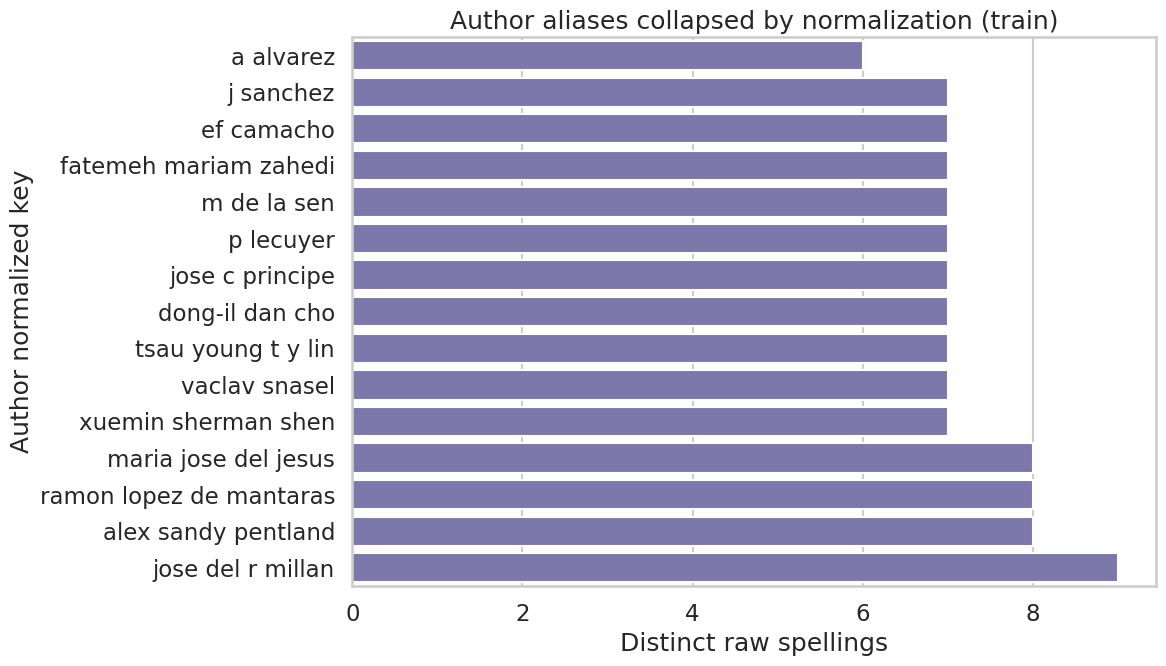

In [68]:
top_author_alias = author_alias_summary.head(15).sort_values("n_variants", ascending=True)

plt.figure(figsize=(12, 7))
sns.barplot(data=top_author_alias, x="n_variants", y="author_norm", color="#7570B3")
plt.title("Author aliases collapsed by normalization (train)")
plt.xlabel("Distinct raw spellings")
plt.ylabel("Author normalized key")
plt.tight_layout()
plt.show()


In [ ]:
del author_alias_rows
del matches
del batch
del row
del author
del writer
del parquet_file

gc.collect()

10186

In [78]:
pa.default_memory_pool().release_unused()

In [ ]:
# df_preview = pd.read_parquet("data/train_normalized.parquet")

In [ ]:
# venue_alias_df = (
#     df_preview.loc[df_preview["venue_norm"] != "", ["venue_norm"]]
#     .drop_duplicates()
# )
# venue_alias_summary = (
#     venue_alias_df.groupby("venue_norm")
#     .agg(
#         n_variants=("venue_clean", "nunique"),
#         examples=("venue_clean", lambda x: " | ".join(sorted(set(list(x)[:10]))[:5]))
#     )
#     .reset_index()
#     .sort_values(["n_variants", "venue_norm"], ascending=[False, True])
# )
# venue_alias_summary = venue_alias_summary[venue_alias_summary["n_variants"] > 1]
# display(venue_alias_summary.head(20))

In [ ]:
# top_venue_alias = venue_alias_summary.head(15).sort_values("n_variants", ascending=True)

# plt.figure(figsize=(12, 7))
# sns.barplot(data=top_venue_alias, x="n_variants", y="venue_norm", color="#E7298A")
# plt.title("Venue aliases collapsed by normalization (train)")
# plt.xlabel("Distinct raw spellings")
# plt.ylabel("Venue normalized key")
# plt.tight_layout()
# plt.show()

## Graph

In [6]:
TRAIN_PATH = "data/train_normalized.parquet"
CENTRALITY_OUTPUT = "data/train_centrality.parquet"
GRAPH_STATS_OUTPUT = "data/graph_stats.parquet"

In [7]:
# Load only id and references columns to save RAM
t0 = time.time()
df_refs = pd.read_parquet(TRAIN_PATH, columns=["id", "references"])
print(f"Loaded {len(df_refs):,} train papers in {time.time()-t0:.1f}s")

valid_ids = set(df_refs["id"].values)
print(f"Valid IDs: {len(valid_ids):,}")

Loaded 3,451,689 train papers in 5.7s
Valid IDs: 3,451,689


In [8]:
# Build edge list from references (only edges where both papers are in train)
t0 = time.time()
edges = []

for _, row in df_refs.iterrows():
    source = row["id"]
    refs = row["references"]

    if not isinstance(refs, (list, np.ndarray)) or len(refs) == 0:
        continue

    for ref in refs:
        ref_str = str(ref).strip()
        if ref_str in valid_ids and ref_str != source:
            edges.append((source, ref_str))

print(f"Edge list built in {time.time()-t0:.1f}s")
print(f"Total edges: {len(edges):,}")

# Free df_refs, we only need edges now
del df_refs
gc.collect()

# Create edge DataFrame
edges_df = pd.DataFrame(edges, columns=["src", "dst"])
del edges
print(f"Edge DataFrame shape: {edges_df.shape}")

Edge list built in 73.6s
Total edges: 32,411,600
Edge DataFrame shape: (32411600, 2)


In [9]:
# cuGraph needs integer node IDs, so we create a mapping
all_nodes = list(valid_ids)
node_to_int = {node: i for i, node in enumerate(all_nodes)}
int_to_node = {i: node for node, i in node_to_int.items()}

# Map string IDs to integers
edges_df["src_int"] = edges_df["src"].map(node_to_int)
edges_df["dst_int"] = edges_df["dst"].map(node_to_int)

# Drop string columns to save memory
edges_int = edges_df[["src_int", "dst_int"]].rename(
    columns={"src_int": "src", "dst_int": "dst"}
)
del edges_df

print(f"Nodes: {len(all_nodes):,}")
print(f"Edges: {len(edges_int):,}")

Nodes: 3,451,689
Edges: 32,411,600


In [10]:
t0 = time.time()

# Convert to cuDF DataFrame (moves data to GPU)
edges_cudf = cudf.DataFrame(edges_int)
del edges_int

# Create directed graph
G = cugraph.Graph(directed=True)
G.from_cudf_edgelist(edges_cudf, source="src", destination="dst")

print(f"cuGraph graph built in {time.time()-t0:.1f}s")
print(f"  Nodes: {G.number_of_vertices():,}")
print(f"  Edges: {G.number_of_edges():,}")
print(f"  Density: {G.number_of_edges() / (G.number_of_vertices() * (G.number_of_vertices()-1)):.8f}")

del edges_cudf
gc.collect()

cuGraph graph built in 0.8s
  Nodes: 3,377,161
  Edges: 32,411,600
  Density: 0.00000284


0

In [11]:
t0 = time.time()

# Weakly connected components (cuGraph needs undirected for WCC)
G_undirected = G.to_undirected()
wcc_df = cugraph.weakly_connected_components(G_undirected)
del G_undirected

# Analyze components
comp_sizes = wcc_df.groupby("labels").size().reset_index(name="size")
comp_sizes = comp_sizes.sort_values("size", ascending=False).reset_index(drop=True)

# Convert to pandas for analysis
comp_sizes_pd = comp_sizes.to_pandas() if hasattr(comp_sizes, 'to_pandas') else comp_sizes

n_components = len(comp_sizes_pd)
largest = comp_sizes_pd.iloc[0]["size"]
total_nodes = comp_sizes_pd["size"].sum()

print(f"Connected components analysis ({time.time()-t0:.1f}s):")
print(f"  Total components: {n_components:,}")
print(f"  Largest component: {largest:,} nodes ({largest/total_nodes*100:.1f}%)")
if n_components > 1:
    print(f"  2nd largest: {comp_sizes_pd.iloc[1]['size']:,} nodes")

# Size breakdown
isolated = (comp_sizes_pd["size"] == 1).sum()
small = ((comp_sizes_pd["size"] > 1) & (comp_sizes_pd["size"] <= 10)).sum()
medium = ((comp_sizes_pd["size"] > 10) & (comp_sizes_pd["size"] <= 100)).sum()
large = (comp_sizes_pd["size"] > 100).sum()

print(f"\n  Isolated (size=1): {isolated:,}")
print(f"  Small (2-10):      {small:,}")
print(f"  Medium (11-100):   {medium:,}")
print(f"  Large (>100):      {large:,}")

Connected components analysis (1.8s):
  Total components: 4,548
  Largest component: 3,366,459 nodes (99.7%)
  2nd largest: 18 nodes

  Isolated (size=1): 0
  Small (2-10):      4,540
  Medium (11-100):   7
  Large (>100):      1


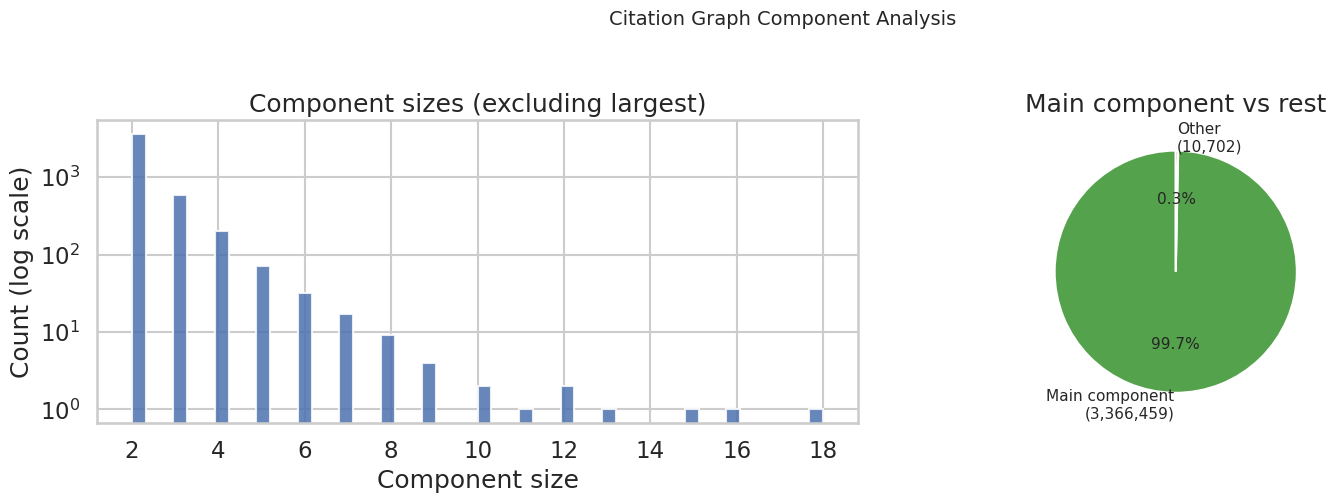

In [12]:
#sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: histogram of component sizes (excluding largest)
small_comps = comp_sizes_pd[comp_sizes_pd["size"] < largest]["size"].values
if len(small_comps) > 0:
    axes[0].hist(small_comps, bins=50, color="#4C72B0", alpha=0.85, log=True)
    axes[0].set_title("Component sizes (excluding largest)")
    axes[0].set_xlabel("Component size")
    axes[0].set_ylabel("Count (log scale)")
else:
    axes[0].text(0.5, 0.5, "Only one component", ha="center", va="center", fontsize=14)
    axes[0].set_title("Component sizes (excluding largest)")

# Right: pie chart
rest = total_nodes - largest
axes[1].pie(
    [largest, rest],
    labels=[f"Main component\n({int(largest):,})", f"Other\n({int(rest):,})"],
    colors=["#54A24B", "#E45756"],
    autopct="%1.1f%%",
    startangle=90,
    textprops={"fontsize": 11}
)
axes[1].set_title("Main component vs rest")

plt.suptitle("Citation Graph Component Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


In [14]:
# Compute Centrality Measures

print("Computing centrality measures on GPU...\n")

# ── In-degree & Out-degree
print("In-degree & Out-degree...")
t0 = time.time()
in_degree = G.in_degree()
out_degree = G.out_degree()

# Convert to pandas
in_deg_pd = in_degree.to_pandas() if hasattr(in_degree, 'to_pandas') else in_degree
out_deg_pd = out_degree.to_pandas() if hasattr(out_degree, 'to_pandas') else out_degree

in_deg_dict = dict(zip(in_deg_pd["vertex"], in_deg_pd["degree"]))
out_deg_dict = dict(zip(out_deg_pd["vertex"], out_deg_pd["degree"]))
print(f"  Done in {time.time()-t0:.1f}s")
del in_degree, out_degree, in_deg_pd, out_deg_pd

# ── PageRank
print("PageRank...")
t0 = time.time()
pagerank_df = cugraph.pagerank(G, alpha=0.85, max_iter=100, tol=1e-06)

pr_pd = pagerank_df.to_pandas() if hasattr(pagerank_df, 'to_pandas') else pagerank_df
pr_dict = dict(zip(pr_pd["vertex"], pr_pd["pagerank"]))
print(f"  Done in {time.time()-t0:.1f}s")
del pagerank_df, pr_pd

# ── Betweenness Centrality
n_vertices = G.number_of_vertices()
k_betweenness = min(5000, n_vertices)
print(f"Betweenness centrality (k={k_betweenness:,})...")
t0 = time.time()
bc_df = cugraph.betweenness_centrality(G, k=k_betweenness, normalized=True, seed=42)

bc_pd = bc_df.to_pandas() if hasattr(bc_df, 'to_pandas') else bc_df
bc_dict = dict(zip(bc_pd["vertex"], bc_pd["betweenness_centrality"]))
print(f"  Done in {time.time()-t0:.1f}s")
del bc_df, bc_pd

print("\nAll centrality measures computed!")

# Free GPU memory
del G
gc.collect()

Computing centrality measures on GPU...

In-degree & Out-degree...
  Done in 0.9s
PageRank...
  Done in 0.7s
Betweenness centrality (k=5,000)...
  Done in 189.6s

All centrality measures computed!


3389

In [15]:
# Build centrality for each paper (map int IDs back to string IDs)
centrality_rows = []

for node_str in all_nodes:
    node_int = node_to_int[node_str]
    centrality_rows.append({
        "id": node_str,
        "in_degree": in_deg_dict.get(node_int, 0),
        "out_degree": out_deg_dict.get(node_int, 0),
        "pagerank": pr_dict.get(node_int, 0.0),
        "betweenness": bc_dict.get(node_int, 0.0),
    })

centrality_df = pd.DataFrame(centrality_rows)
del centrality_rows, in_deg_dict, out_deg_dict, pr_dict, bc_dict

print(f"Centrality DataFrame shape: {centrality_df.shape}")
display(centrality_df.describe().round(6))

# Save
centrality_df.to_parquet(CENTRALITY_OUTPUT, index=False)
print(f"\nCentrality saved to {CENTRALITY_OUTPUT}")
print(f"Size: {Path(CENTRALITY_OUTPUT).stat().st_size / 1024**2:.1f} MB")

Centrality DataFrame shape: (3451689, 5)


,in_degree,out_degree,pagerank,betweenness
count,3.451689e+06,3.451689e+06,3.451689e+06,3.451689e+06
mean,9.390070e+00,9.390070e+00,0.000000e+00,0.000000e+00
std,5.400405e+01,1.049477e+01,3.000000e-06,0.000000e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+00,7.000000e+00,0.000000e+00,0.000000e+00
75%,7.000000e+00,1.300000e+01,0.000000e+00,0.000000e+00
max,2.275800e+04,1.565000e+03,1.678000e-03,8.000000e-05



Centrality saved to data/train_centrality.parquet
Size: 76.9 MB


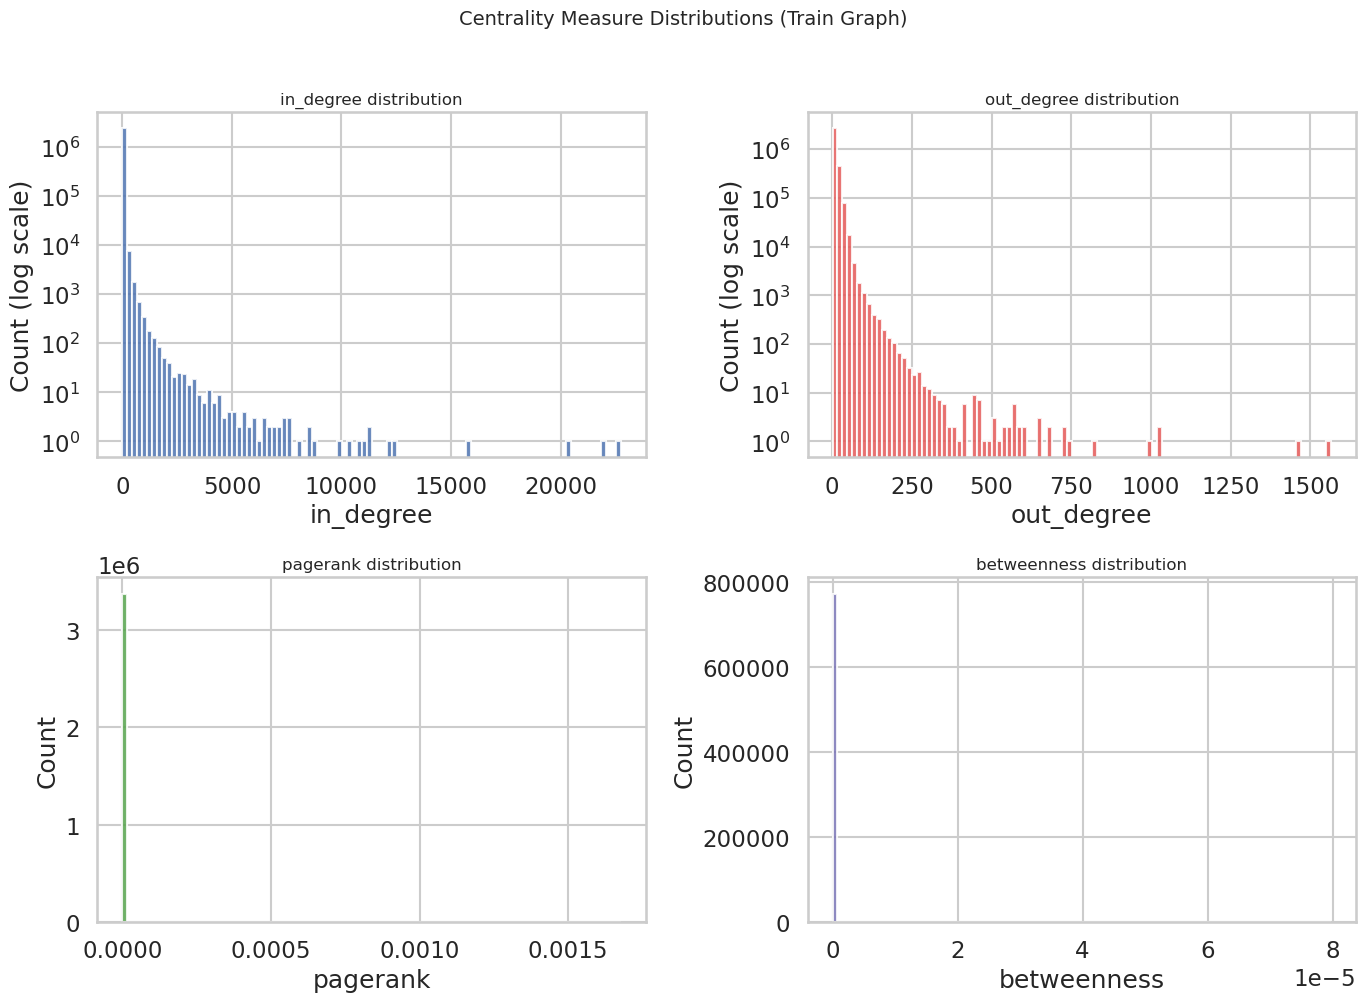

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col, color in zip(axes.flatten(),
                           ["in_degree", "out_degree", "pagerank", "betweenness"],
                           ["#4C72B0", "#E45756", "#54A24B", "#7570B3"]):
    data = centrality_df[col]
    if col in ["in_degree", "out_degree"]:
        ax.hist(data[data > 0], bins=100, color=color, alpha=0.85, log=True)
        ax.set_ylabel("Count (log scale)")
    else:
        ax.hist(data[data > 0], bins=100, color=color, alpha=0.85)
        ax.set_ylabel("Count")
    ax.set_title(f"{col} distribution", fontsize=12)
    ax.set_xlabel(col)

plt.suptitle("Centrality Measure Distributions (Train Graph)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Free memory
#del centrality_df
#gc.collect()
#print("Memory freed. Centrality is saved on disk.")


In [5]:
# import graphistry
# con = duckdb.connect()


# print("1. Finding the absolute Top 1 node...")
# # We changed LIMIT 5 to LIMIT 1
# top_1_query = """
#     SELECT node, COUNT(*) as degree
#     FROM (
#         SELECT src AS node FROM edges_view
#         UNION ALL
#         SELECT dst AS node FROM edges_view
#     )
#     GROUP BY node
#     ORDER BY degree DESC
#     LIMIT 1
# """
# top_1_node = con.execute(top_1_query).df()['node'].iloc[0]
# print(f"Target Node: {top_1_node}")

# print("2. Extracting network tree (Hop 1 and Hop 2)...")
# hop_query = f"""
#     WITH Hop1 AS (
#         SELECT dst AS node FROM edges_view WHERE src = '{top_1_node}'
#         UNION
#         SELECT src AS node FROM edges_view WHERE dst = '{top_1_node}'
#     ),
#     Hop2 AS (
#         SELECT e.dst AS node FROM edges_view e JOIN Hop1 h ON e.src = h.node
#         UNION
#         SELECT e.src AS node FROM edges_view e JOIN Hop1 h ON e.dst = h.node
#     )
#     SELECT 'hop1' as level, node FROM Hop1 WHERE node != '{top_1_node}'
#     UNION
#     SELECT 'hop2' as level, node FROM Hop2 WHERE node != '{top_1_node}' AND node NOT IN (SELECT node FROM Hop1)
# """
# results = con.execute(hop_query).df()

# hop_1_list = results[results['level'] == 'hop1']['node'].tolist()
# hop_2_list = results[results['level'] == 'hop2']['node'].tolist()

# print("3. Tagging nodes for visualization...")
# node_records = []
# seen_nodes = set()

# # Tag the 1 Target Node
# node_records.append({"id": top_1_node, "type": "Target (Top 1)", "size": 30})
# seen_nodes.add(top_1_node)

# # Tag Hop 1 and Hop 2
# for h1 in hop_1_list:
#     if h1 not in seen_nodes:
#         node_records.append({"id": h1, "type": "1st Degree", "size": 15})
#         seen_nodes.add(h1)
        
# for h2 in hop_2_list:
#     if h2 not in seen_nodes:
#         node_records.append({"id": h2, "type": "2nd Degree", "size": 5})
#         seen_nodes.add(h2)

# nodes_df = pd.DataFrame(node_records)

# print("4. Fetching connecting edges...")
# con.register("plot_nodes", nodes_df)
# edges_query = """
#     SELECT e.src, e.dst
#     FROM edges_view e
#     JOIN plot_nodes n1 ON e.src = n1.id
#     JOIN plot_nodes n2 ON e.dst = n2.id
# """
# tree_edges_df = con.execute(edges_query).df()

# print("5. Plotting with Graphistry...")
# # Update our color map to match the new Top 1 label
# category_colors = {
#     "Target (Top 1)": "red",
#     "1st Degree": "blue",
#     "2nd Degree": "silver"
# }

# g = graphistry.edges(tree_edges_df, 'src', 'dst') \
#               .nodes(nodes_df, 'id') \
#               .bind(
#                   point_title='id',
#                   point_size='size'
#               ) \
#               .encode_point_color(
#                   'type',
#                   categorical_mapping=category_colors,
#                   default_mapping="black"
#               ) \
#               .settings(url_params={
#                   'bg': '%23E5E5E5',
#                   'edgeOpacity': 0.05,
#                   'pointOpacity': 0.8      
#               })

# g.plot()

## couple creation (duckDB)


This step creates supervised paper pairs for citation prediction.

Each pair has:

| Column | Meaning |
|--------|---------|
| `source_id` | Paper that may cite another paper |
| `target_id` | Candidate cited paper |
| `label` | `1` if source cites target, `0` otherwise |

Instead of using all citation pairs, we sample a smaller and more informative dataset:

- **Positive pairs** are sampled from real citations using `POSITIVE_SAMPLE_PERCENT`.
- **Negative pairs** are matched hard negatives. For each sampled positive pair,
  the negative target is not cited by the source, has a similar target year, and
  preserves the positive pair's `same_venue` status. This prevents `same_venue`
  from becoming a shortcut for the sampling procedure.

This creates more realistic negative examples and reduces RAM/training cost.

The final output still contains only:

```text
source_id, target_id, label


In [19]:
POSITIVE_SAMPLE_PERCENT = 20
TARGET_POOL_PERCENT = 20
NEGATIVE_RATIO = 1
RANDOM_SEED = 42
FORCE_REGENERATE_PAIRS = True

def generate_pairs_graph_aware_duckdb(
    parquet_path,
    centrality_path,
    output_path,
    positive_sample_percent=5,
    target_pool_percent=5,
    neg_ratio=1,
    seed=42,
):
    con = duckdb.connect()

    Path(output_path).unlink(missing_ok=True)

    con.execute(f"""
        CREATE TABLE papers AS
        SELECT id, "references", year, venue_norm, keywords_norm
        FROM '{parquet_path}'
    """)

    con.execute("""
        CREATE TABLE valid_ids AS
        SELECT DISTINCT id
        FROM papers
    """)

    con.execute(f"""
        CREATE TABLE centrality AS
        SELECT id, in_degree, out_degree, pagerank, betweenness
        FROM '{centrality_path}'
    """)

    con.execute("""
        CREATE TABLE positive_all AS
        SELECT
            p.id AS source_id,
            ref.ref_id AS target_id,
            1 AS label,
            COALESCE(c.in_degree, 0) AS target_in_degree,
            COALESCE(c.pagerank, 0.0) AS target_pagerank,
            CASE
                WHEN COALESCE(c.in_degree, 0) = 0 THEN 'zero'
                WHEN COALESCE(c.in_degree, 0) <= 5 THEN 'low'
                WHEN COALESCE(c.in_degree, 0) <= 50 THEN 'mid'
                ELSE 'high'
            END AS target_popularity_bucket
        FROM papers p,
             LATERAL UNNEST(p."references") AS ref(ref_id)
        LEFT JOIN centrality c ON ref.ref_id = c.id
        WHERE p."references" IS NOT NULL
          AND ref.ref_id IN (SELECT id FROM valid_ids)
          AND ref.ref_id != p.id
    """)

    con.execute(f"""
        CREATE TABLE positive_pairs AS
        SELECT source_id, target_id, label
        FROM positive_all
        USING SAMPLE {positive_sample_percent} PERCENT (BERNOULLI, {seed})
    """)

    n_positive = con.execute("SELECT COUNT(*) FROM positive_pairs").fetchone()[0]
    n_negative = n_positive * neg_ratio

    print(f"Positive pairs sampled: {n_positive:,}")
    print(f"Target negative pairs: {n_negative:,}")

    con.execute(f"""
        CREATE TABLE target_pool AS
        SELECT id, year, venue_norm
        FROM papers
        WHERE venue_norm != ''
        USING SAMPLE {target_pool_percent} PERCENT (BERNOULLI, {seed})
    """)

    n_pool = con.execute("SELECT COUNT(*) FROM target_pool").fetchone()[0]
    print(f"Target pool size: {n_pool:,}")

    con.execute(f"""
        CREATE TABLE negative_pairs AS
        WITH positives_enriched AS (
            SELECT
                pp.source_id,
                pp.target_id AS positive_target_id,
                CAST(ps.year AS INTEGER) AS source_year,
                CAST(pt.year AS INTEGER) AS positive_target_year,
                COALESCE(ps.venue_norm, '') AS source_venue,
                CASE
                    WHEN COALESCE(ps.venue_norm, '') != ''
                     AND ps.venue_norm = pt.venue_norm
                    THEN 1 ELSE 0
                END AS positive_same_venue
            FROM positive_pairs pp
            JOIN papers ps ON pp.source_id = ps.id
            JOIN papers pt ON pp.target_id = pt.id
        ),
        candidates AS (
            SELECT
                pe.source_id,
                t.id AS target_id,
                0 AS label,
                ROW_NUMBER() OVER (
                    PARTITION BY pe.source_id, pe.positive_target_id
                    ORDER BY random()
                ) AS rn
            FROM positives_enriched pe
            JOIN target_pool t
              ON t.id != pe.source_id
             AND t.id != pe.positive_target_id
             AND CAST(t.year AS INTEGER) <= pe.source_year
             AND ABS(CAST(t.year AS INTEGER) - pe.positive_target_year) <= 1
             AND (
                    (pe.positive_same_venue = 1 AND t.venue_norm = pe.source_venue)
                 OR (pe.positive_same_venue = 0 AND t.venue_norm != pe.source_venue)
             )
            WHERE pe.source_year IS NOT NULL
              AND pe.positive_target_year IS NOT NULL
              AND NOT EXISTS (
                  SELECT 1
                  FROM positive_all pp
                  WHERE pp.source_id = pe.source_id
                    AND pp.target_id = t.id
              )
        ),
        one_negative_per_positive AS (
            SELECT source_id, target_id, label
            FROM candidates
            WHERE rn <= {neg_ratio}
        ),
        deduped AS (
            SELECT
                source_id,
                target_id,
                label,
                ROW_NUMBER() OVER (
                    PARTITION BY source_id, target_id
                    ORDER BY random()
                ) AS pair_rn
            FROM one_negative_per_positive
        )
        SELECT source_id, target_id, label
        FROM deduped
        WHERE pair_rn = 1
        ORDER BY random()
        LIMIT {n_negative}
    """)

    n_neg_actual = con.execute("SELECT COUNT(*) FROM negative_pairs").fetchone()[0]
    print(f"Negative pairs sampled: {n_neg_actual:,}")

    con.execute(f"""
        COPY (
            SELECT *
            FROM (
                SELECT * FROM positive_pairs
                UNION ALL
                SELECT * FROM negative_pairs
            )
            ORDER BY RANDOM()
        ) TO '{output_path}' (FORMAT PARQUET)
    """)

    total = n_positive + n_neg_actual

    print(f"Total pairs: {total:,} saved to {output_path}")
    print(
        f"Label distribution: "
        f"1={n_positive:,} ({n_positive / total * 100:.1f}%), "
        f"0={n_neg_actual:,} ({n_neg_actual / total * 100:.1f}%)"
    )

    con.close()


In [20]:
for split in ["train", "val", "test"]:
    output_path = f"data/{split}_pairs.parquet"

    if os.path.exists(output_path) and not FORCE_REGENERATE_PAIRS:
        print(f"[{split}] pairs already exists, skipping")
        continue

    print(f"Generating pairs for: {split}")

    generate_pairs_graph_aware_duckdb(
        parquet_path=f"data/{split}_normalized.parquet",
        centrality_path="data/train_centrality.parquet",
        output_path=output_path,
        positive_sample_percent=POSITIVE_SAMPLE_PERCENT,
        target_pool_percent=TARGET_POOL_PERCENT,
        neg_ratio=NEGATIVE_RATIO,
        seed=RANDOM_SEED,
    )

Generating pairs for: train


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Positive pairs sampled: 6,482,797
Target negative pairs: 6,482,797
Target pool size: 172,396


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Negative pairs sampled: 6,482,797
Total pairs: 12,965,594 saved to data/train_pairs.parquet
Label distribution: 1=6,482,797 (50.0%), 0=6,482,797 (50.0%)
Generating pairs for: val
Positive pairs sampled: 42,090
Target negative pairs: 42,090
Target pool size: 16,932
Negative pairs sampled: 42,090
Total pairs: 84,180 saved to data/val_pairs.parquet
Label distribution: 1=42,090 (50.0%), 0=42,090 (50.0%)
Generating pairs for: test
Positive pairs sampled: 267,576
Target negative pairs: 267,576
Target pool size: 36,899
Negative pairs sampled: 267,576
Total pairs: 535,152 saved to data/test_pairs.parquet
Label distribution: 1=267,576 (50.0%), 0=267,576 (50.0%)


## Feature Extraction



For each pair (source_paper, target_paper) we extract features that capture
different reasons why a citation might occur. The features are divided into
3 groups, which will later be used to train separate and combined models.

**Traditional Features (9)**

Metadata-based features that don't require text analysis or network structure:

| Feature | Description |
|---------|-------------|
| `year_diff` | year(source) − year(target). Papers cite older work, so positive values indicate a valid citation direction. |
| `is_recent` | 1 if the two papers are within 3 years of each other. Captures recency bias. |
| `target_age` | 2025 − year(target). Controls for the different citation dynamics of old vs new papers. |
| `same_venue` | 1 if both papers share the same venue. Same-community papers cite each other more. |
| `same_doc_type` | 1 if both papers share the same document type (journal, conference, etc.). |
| `n_citation_target` | In-sample citation count of the target paper. Popular papers attract more citations. |
| `n_refs_source` | Number of references the source paper has. More references = higher chance of citing any given paper. |
| `n_authors_source` | Number of authors on the source paper. |
| `n_authors_target` | Number of authors on the target paper. |

**Textual Features (3)**

Content-similarity features derived from the papers' text:

| Feature | Description |
|---------|-------------|
| `abstract_sim` | Cosine similarity between TF-IDF vectors of the two abstracts. Strongest semantic signal. |
| `keyword_jaccard` | Jaccard similarity between keyword sets. Measures topical overlap via curated descriptors. |
| `title_sim` | Cosine similarity between TF-IDF vectors of the two titles. |

**Graph Features (11)**

Structural features from the citation network and co-authorship:

| Feature | Description |
|---------|-------------|
| `common_refs` | Number of shared references (bibliographic coupling). Strong co-citation signal. |
| `has_shared_author` | 1 if at least one author appears in both papers. Self-citation is common. |
| `shared_orgs` | 1 if any authors share the same organization. |
| `in_degree_source` | Incoming citations of source paper in the train graph. |
| `in_degree_target` | Incoming citations of target paper in the train graph. |
| `out_degree_source` | Outgoing references of source paper in the train graph. |
| `out_degree_target` | Outgoing references of target paper in the train graph. |
| `pagerank_source` | PageRank of source paper. Recursive importance measure. |
| `pagerank_target` | PageRank of target paper. |
| `betweenness_source` | Betweenness centrality of source paper. Bridge between communities. |
| `betweenness_target` | Betweenness centrality of target paper. |

**Pipeline Strategy**

To handle RAM constraints with millions of papers, we split extraction into two phases:
- **Phase 1 (DuckDB)**: traditional features + graph centrality lookups via SQL joins.
  DuckDB works directly on parquet files without loading everything into RAM.
- **Phase 2 (Python + GPU)**: textual similarities (TF-IDF + cosine on GPU),
  set-based features (common_refs, shared_author, shared_orgs) via Python dicts.

Centrality measures come from the **train graph only** to prevent data leakage.
Val/test papers not present in the train graph receive centrality = 0.

Each set (train, val, test) is processed independently and saved before
loading the next one, keeping peak RAM usage low.

**Total: 23 features per pair.**

In [14]:
# Paths
DATA_DIR = Path("data")
TRAIN_NORMALIZED = DATA_DIR / "train_normalized.parquet"
VAL_NORMALIZED   = DATA_DIR / "val_normalized.parquet"
TEST_NORMALIZED  = DATA_DIR / "test_normalized.parquet"

TRAIN_PAIRS = DATA_DIR / "train_pairs.parquet"
VAL_PAIRS   = DATA_DIR / "val_pairs.parquet"
TEST_PAIRS  = DATA_DIR / "test_pairs.parquet"

CENTRALITY_PATH = DATA_DIR / "train_centrality.parquet"


# TF-IDF config
TF_IDF_MAX_FEATURES = 5000


# Phase 1 outputs
PHASE1_OUTPUTS = {
    "train": DATA_DIR / "train_features_phase1.parquet",
    "val":   DATA_DIR / "val_features_phase1.parquet",
    "test":  DATA_DIR / "test_features_phase1.parquet",
}
FORCE_REGENERATE_FEATURES = True

In [21]:
def extract_traditional_features_duckdb(pairs_path, normalized_path, centrality_path, output_path):
    con = duckdb.connect()
    t0 = time.time()
    analysis_year = globals().get("CURRENT_YEAR", 2026)

    tmp_path = str(output_path).replace(".parquet", "_tmp.parquet")
    Path(tmp_path).unlink(missing_ok=True)
    Path(output_path).unlink(missing_ok=True)

    con.execute(f"""
        COPY (
            SELECT
                p.source_id,
                p.target_id,
                p.label,
                CAST(s.year AS INTEGER) AS source_year_tmp,
                CAST(t.year AS INTEGER) AS target_year_tmp,

                -- TRADITIONAL
                COALESCE(CAST(s.year AS INTEGER), 0)
                    - COALESCE(CAST(t.year AS INTEGER), 0) AS year_diff,

                CASE WHEN ABS(
                    COALESCE(CAST(s.year AS INTEGER), 0)
                    - COALESCE(CAST(t.year AS INTEGER), 0)
                ) <= 3 THEN 1 ELSE 0 END AS is_recent,

                {analysis_year} - COALESCE(CAST(t.year AS INTEGER), {analysis_year}) AS target_age,

                CASE WHEN s.venue_norm = t.venue_norm
                     AND s.venue_norm IS NOT NULL
                     AND s.venue_norm != ''
                     THEN 1 ELSE 0 END AS same_venue,

                CASE WHEN s.doc_type = t.doc_type
                     AND s.doc_type IS NOT NULL
                     AND s.doc_type != ''
                     THEN 1 ELSE 0 END AS same_doc_type,

                COALESCE(s.n_authors, 0)    AS n_authors_source,
                COALESCE(t.n_authors, 0)    AS n_authors_target

            FROM '{pairs_path}' p
            LEFT JOIN '{normalized_path}' s
              ON p.source_id = s.id
            LEFT JOIN '{normalized_path}' t
              ON p.target_id = t.id
        ) TO '{tmp_path}' (FORMAT PARQUET)
    """)

    con.execute(f"""
        CREATE TABLE citation_edges AS
        SELECT
            p.id AS citing_id,
            CAST(p.year AS INTEGER) AS citing_year,
            ref.ref_id AS target_id
        FROM read_parquet('data/*_normalized.parquet') p,
             LATERAL UNNEST(p."references") AS ref(ref_id)
        WHERE p."references" IS NOT NULL
          AND ref.ref_id IS NOT NULL
          AND p.year IS NOT NULL
    """)

    con.execute(f"""
        CREATE TABLE target_prior_counts AS
        SELECT
            f.source_id,
            f.target_id,
            COUNT(e.citing_id) AS target_prior_citations
        FROM '{tmp_path}' f
        LEFT JOIN citation_edges e
          ON e.target_id = f.target_id
         AND e.citing_year < f.source_year_tmp
        GROUP BY f.source_id, f.target_id
    """)

    con.execute(f"""
        COPY (
            SELECT
                f.source_id,
                f.target_id,
                f.label,
                f.year_diff,
                f.is_recent,
                f.target_age,
                f.same_venue,
                f.same_doc_type,
                f.n_authors_source,
                f.n_authors_target,
                COALESCE(tpc.target_prior_citations, 0) AS target_prior_citations
            FROM '{tmp_path}' f
            LEFT JOIN target_prior_counts tpc
              ON f.source_id = tpc.source_id
             AND f.target_id = tpc.target_id
        ) TO '{output_path}' (FORMAT PARQUET)
    """)

    Path(tmp_path).unlink(missing_ok=True)

    elapsed = time.time() - t0
    n_rows = con.execute(f"SELECT COUNT(*) FROM '{output_path}'").fetchone()[0]
    con.close()

    print(f"  Rows: {n_rows:,} | Time: {elapsed:.1f}s")
    print(f"  Saved -> {output_path}")

In [22]:
split, pairs, normalized = "train", TRAIN_PAIRS, TRAIN_NORMALIZED
output = PHASE1_OUTPUTS[split]

if output.exists() and not FORCE_REGENERATE_FEATURES:
    print(f"[SKIP] {output} already exists.")
else:
    print(f"Phase 1 — {split}")
    extract_traditional_features_duckdb(pairs, normalized, CENTRALITY_PATH, output)

Phase 1 — train
  Rows: 12,965,594 | Time: 2.9s
  Saved -> data/train_features_phase1.parquet


In [23]:
split, pairs, normalized = "val", VAL_PAIRS, VAL_NORMALIZED
output = PHASE1_OUTPUTS[split]

if output.exists() and not FORCE_REGENERATE_FEATURES:
    print(f"[SKIP] {output} already exists.")
else:
    print(f"Phase 1 — {split}")
    extract_traditional_features_duckdb(pairs, normalized, CENTRALITY_PATH, output)

Phase 1 — val
  Rows: 84,180 | Time: 0.3s
  Saved -> data/val_features_phase1.parquet


In [24]:
split, pairs, normalized = "test", TEST_PAIRS, TEST_NORMALIZED
output = PHASE1_OUTPUTS[split]

if output.exists() and not FORCE_REGENERATE_FEATURES:
    print(f"[SKIP] {output} already exists.")
else:
    print(f"Phase 1 — {split}")
    extract_traditional_features_duckdb(pairs, normalized, CENTRALITY_PATH, output)

Phase 1 — test
  Rows: 535,152 | Time: 0.4s
  Saved -> data/test_features_phase1.parquet


phase 2


In [25]:
# Helper functions for second phase 

def jaccard(set_a, set_b):
    """Jaccard similarity between two sets."""
    if not set_a and not set_b:
        return 0.0
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)
    return intersection / union if union > 0 else 0.0


def build_lookup_sets(df):
    """
    Build dictionaries for fast per-paper lookups.
    Only loads the columns we need.
    """
    ref_sets = {}
    author_sets = {}
    org_sets = {}
    keyword_sets = {}
    
    for _, row in df.iterrows():
        pid = row["id"]
        
        # References
        refs = row.get("references", [])
        if isinstance(refs, (list, np.ndarray)) and len(refs) > 0:
            ref_sets[pid] = set(str(r).strip() for r in refs)
        else:
            ref_sets[pid] = set()
        
        # Authors
        a_names = row.get("author_names_norm", [])
        author_sets[pid] = set(a_names) if isinstance(a_names, list) else set()
        
        # Organizations
        a_orgs = row.get("author_orgs_clean", [])
        org_sets[pid] = set(a_orgs) if isinstance(a_orgs, list) else set()
        
        # Keywords
        kw = row.get("keywords_norm", [])
        keyword_sets[pid] = set(kw) if isinstance(kw, list) else set()
    
    return ref_sets, author_sets, org_sets, keyword_sets


def precompute_gpu_similarities(pairs_df, id_to_idx, title_tfidf, abstract_tfidf, device):
    """
    Batch-compute cosine similarities on GPU.
    Processes in chunks to avoid VRAM overflow.
    """
    src_indices = np.array([id_to_idx[sid] for sid in pairs_df["source_id"]])
    tgt_indices = np.array([id_to_idx[tid] for tid in pairs_df["target_id"]])
    
    results = {}
    CHUNK_SIZE = 512
    
    for name, tfidf_matrix in [("title_sim", title_tfidf), ("abstract_sim", abstract_tfidf)]:
        print(f"    Computing {name} on GPU...")
        t0 = time.time()
        
        all_sims = []
        
        for chunk_start in range(0, len(src_indices), CHUNK_SIZE):
            chunk_end = min(chunk_start + CHUNK_SIZE, len(src_indices))
            
            src_idx_chunk = src_indices[chunk_start:chunk_end]
            tgt_idx_chunk = tgt_indices[chunk_start:chunk_end]
            
            src_vecs = torch.tensor(
                tfidf_matrix[src_idx_chunk].toarray(), dtype=torch.float32, device=device
            )
            tgt_vecs = torch.tensor(
                tfidf_matrix[tgt_idx_chunk].toarray(), dtype=torch.float32, device=device
            )
            
            src_norm = torch.nn.functional.normalize(src_vecs, p=2, dim=1)
            tgt_norm = torch.nn.functional.normalize(tgt_vecs, p=2, dim=1)
            
            sims = (src_norm * tgt_norm).sum(dim=1)
            all_sims.append(sims.cpu().numpy())
            
            del src_vecs, tgt_vecs, src_norm, tgt_norm, sims
            torch.cuda.empty_cache()
        
        results[name] = np.concatenate(all_sims)
        print(f"      Done in {time.time()-t0:.1f}s ({len(src_indices):,} pairs)")
    
    return results


In [29]:
# Phase 2 — Textual + Set-based features
def extract_text_graph_features(split_name, normalized_path, phase1_path, output_path, 
                                 train_title_vectorizer=None, train_abstract_vectorizer=None):
    """
    Extract textual and set-based features for a given split.
    
    For train: fits TF-IDF vectorizers and returns them.
    For val/test: uses the train vectorizers (transform only, no fit).
    
    Produces: abstract_sim, keyword_jaccard, title_sim,
              common_refs, has_shared_author, shared_orgs
    """
    print(f"\n  Loading {split_name} data...")
    t0 = time.time()
    
    # Load only needed columns
    df = pd.read_parquet(
        normalized_path,
        columns=[
            "id",
            "title_norm",
            "abstract_norm",
            "keywords_norm",
            "author_names_norm",
            "references",
        ]
    )

    print(f"    Loaded {len(df):,} papers in {time.time()-t0:.1f}s")
    
    # Load phase 1 results (has source_id, target_id, label + traditional features)
    phase1 = pd.read_parquet(phase1_path)
    print(f"    Loaded {len(phase1):,} pairs from phase 1")
    
    # Build lookup: paper_id -> row index
    id_to_idx = {pid: i for i, pid in enumerate(df["id"])}
    
    # TF-IDF 
    print(f"\n  Building TF-IDF matrices...")
    
    titles = df["title_norm"].fillna("").values
    abstracts = df["abstract_norm"].fillna("").values
    
    if train_title_vectorizer is None:
        # Train: fit + transform
        title_vectorizer = TfidfVectorizer(
            max_features=TF_IDF_MAX_FEATURES, stop_words="english",
            ngram_range=(1, 2), min_df=2
        )
        title_tfidf = title_vectorizer.fit_transform(titles)
        
        abstract_vectorizer = TfidfVectorizer(
            max_features=TF_IDF_MAX_FEATURES, stop_words="english",
            ngram_range=(1, 2), min_df=2
        )
        abstract_tfidf = abstract_vectorizer.fit_transform(abstracts)
        print("    TF-IDF: fit + transform (train)")
    else:
        # Val/Test: transform only (use train vocabulary)
        title_vectorizer = train_title_vectorizer
        abstract_vectorizer = train_abstract_vectorizer
        title_tfidf = title_vectorizer.transform(titles)
        abstract_tfidf = abstract_vectorizer.transform(abstracts)
        print("    TF-IDF: transform only (using train vocabulary)")
    
    print(f"    Title TF-IDF:    {title_tfidf.shape}")
    print(f"    Abstract TF-IDF: {abstract_tfidf.shape}")
    
    # GPU similarities
    print(f"\n  Computing GPU similarities...")
    gpu_sims = precompute_gpu_similarities(
        phase1, id_to_idx, title_tfidf, abstract_tfidf, device
    )
    
    del title_tfidf, abstract_tfidf, titles, abstracts
    gc.collect()
    torch.cuda.empty_cache()
    
    # Build lookup sets
    print(f"\n  Building lookup sets...")
    t0 = time.time()
    ref_sets, author_sets, org_sets, keyword_sets = build_lookup_sets(df)
    print(f"    Done in {time.time()-t0:.1f}s")
    
    del df
    gc.collect()
    
    # Extract set-based features 
    print(f"\n  Extracting set-based features...")
    t0 = time.time()
    
    n_pairs = len(phase1)
    keyword_jaccards = np.zeros(n_pairs)
    common_refs_arr = np.zeros(n_pairs, dtype=np.int32)
    shared_author_arr = np.zeros(n_pairs, dtype=np.int8)
    shared_orgs_arr = np.zeros(n_pairs, dtype=np.int8)
    
    for i, row in enumerate(phase1.itertuples(index=False)):
        src_id = row.source_id
        tgt_id = row.target_id
        
        # Keyword Jaccard
        keyword_jaccards[i] = jaccard(
            keyword_sets.get(src_id, set()),
            keyword_sets.get(tgt_id, set())
        )
        
        # Common references
        src_refs = ref_sets.get(src_id, set())
        tgt_refs = ref_sets.get(tgt_id, set())
        common_refs_arr[i] = len(src_refs & tgt_refs)
        
        # Shared author
        src_auth = author_sets.get(src_id, set())
        tgt_auth = author_sets.get(tgt_id, set())
        shared_author_arr[i] = int(len(src_auth & tgt_auth) > 0)
        
        # Shared org
        src_org = org_sets.get(src_id, set())
        tgt_org = org_sets.get(tgt_id, set())
        shared_orgs_arr[i] = int(len(src_org & tgt_org) > 0)
        
        if (i + 1) % 100_000 == 0:
            print(f"    [{i+1:,}/{n_pairs:,}] pairs processed")
    
    print(f"    Done in {time.time()-t0:.1f}s")
    
    del ref_sets, author_sets, org_sets, keyword_sets
    gc.collect()
    
    # Merge everything 
    print(f"\n  Merging features...")
    
    phase1["abstract_sim"] = gpu_sims["abstract_sim"]
    phase1["keyword_jaccard"] = keyword_jaccards
    phase1["title_sim"] = gpu_sims["title_sim"]
    phase1["common_refs"] = common_refs_arr
    phase1["has_shared_author"] = shared_author_arr
    phase1["shared_orgs"] = shared_orgs_arr
    
    del gpu_sims, keyword_jaccards, common_refs_arr, shared_author_arr, shared_orgs_arr
    
    # Save
    phase1.to_parquet(output_path, index=False)
    print(f"\n  Final dataset saved to {output_path}")
    print(f"  Shape: {phase1.shape}")
    print(f"  Size: {Path(output_path).stat().st_size / 1024**2:.1f} MB")
    print(f"  Columns: {list(phase1.columns)}")
    
    del phase1
    gc.collect()
    
    return title_vectorizer, abstract_vectorizer

In [32]:
import joblib

PHASE2_OUTPUTS = {
    "train": DATA_DIR / "train_features_final.parquet",
    "val":   DATA_DIR / "val_features_final.parquet",
    "test":  DATA_DIR / "test_features_final.parquet",
}
VECTORIZER_PATH = DATA_DIR / "tfidf_vectorizers.joblib"

output = PHASE2_OUTPUTS["train"]

if output.exists() and VECTORIZER_PATH.exists():
    print(f"[SKIP] {output} already exists. Loading vectorizers...")
    title_vec, abstract_vec = joblib.load(VECTORIZER_PATH)
else:
    print("Phase 2 — train")
    title_vec, abstract_vec = extract_text_graph_features(
        "train", TRAIN_NORMALIZED,
        PHASE1_OUTPUTS["train"], output
    )
    joblib.dump((title_vec, abstract_vec), VECTORIZER_PATH)
    print(f"  Vectorizers saved → {VECTORIZER_PATH}")

Phase 2 — train

  Loading train data...
    Loaded 3,451,689 papers in 14.4s
    Loaded 12,965,594 pairs from phase 1

  Building TF-IDF matrices...
    TF-IDF: fit + transform (train)
    Title TF-IDF:    (3451689, 5000)
    Abstract TF-IDF: (3451689, 5000)

  Computing GPU similarities...
    Computing title_sim on GPU...
      Done in 181.2s (12,965,594 pairs)
    Computing abstract_sim on GPU...
      Done in 217.3s (12,965,594 pairs)

  Building lookup sets...
    Done in 102.8s

  Extracting set-based features...
    [100,000/12,965,594] pairs processed
    [200,000/12,965,594] pairs processed
    [300,000/12,965,594] pairs processed
    [400,000/12,965,594] pairs processed
    [500,000/12,965,594] pairs processed
    [600,000/12,965,594] pairs processed
    [700,000/12,965,594] pairs processed
    [800,000/12,965,594] pairs processed
    [900,000/12,965,594] pairs processed
    [1,000,000/12,965,594] pairs processed
    [1,100,000/12,965,594] pairs processed
    [1,200,000/12,9

In [33]:
output = PHASE2_OUTPUTS["val"]

if output.exists():
    print(f"[SKIP] {output} already exists.")
else:
    print("Phase 2 — val")
    extract_text_graph_features(
        "val", VAL_NORMALIZED,
        PHASE1_OUTPUTS["val"], output,
        train_title_vectorizer=title_vec,
        train_abstract_vectorizer=abstract_vec
    )

Phase 2 — val

  Loading val data...
    Loaded 335,266 papers in 2.5s
    Loaded 84,180 pairs from phase 1

  Building TF-IDF matrices...
    TF-IDF: transform only (using train vocabulary)
    Title TF-IDF:    (335266, 5000)
    Abstract TF-IDF: (335266, 5000)

  Computing GPU similarities...
    Computing title_sim on GPU...
      Done in 1.2s (84,180 pairs)
    Computing abstract_sim on GPU...
      Done in 1.3s (84,180 pairs)

  Building lookup sets...
    Done in 10.5s

  Extracting set-based features...
    Done in 0.4s

  Merging features...

  Final dataset saved to data/val_features_final.parquet
  Shape: (84180, 26)
  Size: 2.3 MB
  Columns: ['source_id', 'target_id', 'label', 'year_diff', 'is_recent', 'target_age', 'same_venue', 'same_doc_type', 'n_refs_source', 'n_authors_source', 'n_authors_target', 'in_degree_source', 'in_degree_target', 'out_degree_source', 'out_degree_target', 'pagerank_source', 'pagerank_target', 'betweenness_source', 'betweenness_target', 'n_citation

In [34]:
output = PHASE2_OUTPUTS["test"]

if output.exists():
    print(f"[SKIP] {output} already exists.")
else:
    print("Phase 2 — test")
    extract_text_graph_features(
        "test", TEST_NORMALIZED,
        PHASE1_OUTPUTS["test"], output,
        train_title_vectorizer=title_vec,
        train_abstract_vectorizer=abstract_vec
    )

del title_vec, abstract_vec
gc.collect()

Phase 2 — test

  Loading test data...
    Loaded 737,608 papers in 4.8s
    Loaded 535,152 pairs from phase 1

  Building TF-IDF matrices...
    TF-IDF: transform only (using train vocabulary)
    Title TF-IDF:    (737608, 5000)
    Abstract TF-IDF: (737608, 5000)

  Computing GPU similarities...
    Computing title_sim on GPU...
      Done in 7.5s (535,152 pairs)
    Computing abstract_sim on GPU...
      Done in 9.7s (535,152 pairs)

  Building lookup sets...
    Done in 23.3s

  Extracting set-based features...
    [100,000/535,152] pairs processed
    [200,000/535,152] pairs processed
    [300,000/535,152] pairs processed
    [400,000/535,152] pairs processed
    [500,000/535,152] pairs processed
    Done in 2.5s

  Merging features...

  Final dataset saved to data/test_features_final.parquet
  Shape: (535152, 26)
  Size: 17.7 MB
  Columns: ['source_id', 'target_id', 'label', 'year_diff', 'is_recent', 'target_age', 'same_venue', 'same_doc_type', 'n_refs_source', 'n_authors_source

47

In [35]:
# sanity check 
for split in ["train", "val", "test"]:
    path = DATA_DIR / f"{split}_features_final.parquet"
    df = pd.read_parquet(path)
    print(f"\n{split}: {df.shape}")
    print(f"  Label distribution: {df['label'].value_counts().to_dict()}")
    print(f"  Columns: {list(df.columns)}")
    print(f"  Nulls: {df.isnull().sum().sum()}")
    display(df.head(3))
    del df

gc.collect()



train: (12965594, 26)
  Label distribution: {1: 6482797, 0: 6482797}
  Columns: ['source_id', 'target_id', 'label', 'year_diff', 'is_recent', 'target_age', 'same_venue', 'same_doc_type', 'n_refs_source', 'n_authors_source', 'n_authors_target', 'in_degree_source', 'in_degree_target', 'out_degree_source', 'out_degree_target', 'pagerank_source', 'pagerank_target', 'betweenness_source', 'betweenness_target', 'n_citation_target', 'abstract_sim', 'keyword_jaccard', 'title_sim', 'common_refs', 'has_shared_author', 'shared_orgs']
  Nulls: 0


,source_id,target_id,label,year_diff,is_recent,target_age,same_venue,same_doc_type,n_refs_source,n_authors_source,...,pagerank_target,betweenness_source,betweenness_target,n_citation_target,abstract_sim,keyword_jaccard,title_sim,common_refs,has_shared_author,shared_orgs
0,5b67b4b117c44aac1c866cd8,53e9b53bb7602d970407161a,1,11,0,17,0,0,25,3,...,1.167092e-07,0.0,0.000000e+00,2,0.110719,0.0,0.000000,1,0,0
1,5d285c30275ded87f954ad2e,5b3d98cc17c44a510f801a7b,1,1,1,7,0,1,8,2,...,1.188677e-07,0.0,0.000000e+00,1,0.467179,0.0,0.327105,1,0,0
2,602f902aaf79179a99a55a49,53e9b3b2b7602d9703e98e1d,1,14,0,21,0,1,12,2,...,1.351671e-05,0.0,2.961069e-11,199,0.043362,0.0,0.000000,0,0,0



val: (84180, 26)
  Label distribution: {1: 42090, 0: 42090}
  Columns: ['source_id', 'target_id', 'label', 'year_diff', 'is_recent', 'target_age', 'same_venue', 'same_doc_type', 'n_refs_source', 'n_authors_source', 'n_authors_target', 'in_degree_source', 'in_degree_target', 'out_degree_source', 'out_degree_target', 'pagerank_source', 'pagerank_target', 'betweenness_source', 'betweenness_target', 'n_citation_target', 'abstract_sim', 'keyword_jaccard', 'title_sim', 'common_refs', 'has_shared_author', 'shared_orgs']
  Nulls: 0


,source_id,target_id,label,year_diff,is_recent,target_age,same_venue,same_doc_type,n_refs_source,n_authors_source,...,pagerank_target,betweenness_source,betweenness_target,n_citation_target,abstract_sim,keyword_jaccard,title_sim,common_refs,has_shared_author,shared_orgs
0,61c8b4e05244ab9dcb4d91ea,6173ee655244ab9dcb68b2fe,1,0,1,4,0,1,31,2,...,0.0,0.0,0.0,1,0.122299,0.0,0.0,0,0,0
1,5fcf46d091e011f4c80babaa,599c7ce9601a182cd27e794e,1,0,1,4,0,0,13,5,...,0.0,0.0,0.0,5,0.114410,0.0,0.0,2,0,0
2,60cab01d91e011b329373f4a,5e4e5ac53a55ac305df4b6ea,1,0,1,4,0,0,16,2,...,0.0,0.0,0.0,2,0.144968,0.0,0.0,8,0,0



test: (535152, 26)
  Label distribution: {1: 267576, 0: 267576}
  Columns: ['source_id', 'target_id', 'label', 'year_diff', 'is_recent', 'target_age', 'same_venue', 'same_doc_type', 'n_refs_source', 'n_authors_source', 'n_authors_target', 'in_degree_source', 'in_degree_target', 'out_degree_source', 'out_degree_target', 'pagerank_source', 'pagerank_target', 'betweenness_source', 'betweenness_target', 'n_citation_target', 'abstract_sim', 'keyword_jaccard', 'title_sim', 'common_refs', 'has_shared_author', 'shared_orgs']
  Nulls: 0


,source_id,target_id,label,year_diff,is_recent,target_age,same_venue,same_doc_type,n_refs_source,n_authors_source,...,pagerank_target,betweenness_source,betweenness_target,n_citation_target,abstract_sim,keyword_jaccard,title_sim,common_refs,has_shared_author,shared_orgs
0,66a848d201d2a3fbfc07305e,648ce3ffd68f896efa897f4c,1,1,1,2,0,1,49,2,...,0.0,0.0,0.0,3,0.530473,0.0,0.801273,18,0,0
1,653ba60b939a5f4082d5cf7a,64c78b913fda6d7f06db06e3,1,0,1,2,0,1,4,8,...,0.0,0.0,0.0,1,0.384800,0.0,0.504737,0,0,0
2,66026e2e13fb2c6cf671a09d,645d02f2d68f896efa8fb8b9,1,1,1,2,0,1,44,5,...,0.0,0.0,0.0,3,0.036307,0.0,0.000000,0,0,0


0

## Classification 


We train models using different combinations of feature groups to understand
the contribution of each group to the citation prediction task.

**Models**

We use two classifiers with different characteristics:

- **Logistic Regression** (cuML, GPU): a linear model that serves as our
  interpretable baseline. If a simple linear combination of features can
  predict citations well, we don't need complex models. Requires feature
  scaling since it's sensitive to different magnitudes.

- **LightGBM** (GPU): a gradient boosting model, generally the best
  performer on tabular data. Builds trees sequentially, each one correcting
  the errors of the previous. Handles mixed feature types (continuous and
  binary) naturally, doesn't require scaling, and is very fast on GPU.

**Feature Combinations**

We train each model on 7 feature subsets to isolate the contribution
of each group:

| Model | Features | Purpose |
|-------|----------|---------|
| M1 | Traditional | Can metadata alone predict citations? |
| M2 | Text | Can topic similarity alone predict citations? |
| M3 | Graph | Can network structure alone predict citations? |
| M4 | Traditional + Text | Does content improve metadata? |
| M5 | Traditional + Graph | Does network improve metadata? |
| M6 | Text + Graph | How do content and network combine? |
| M7 | All | What is the performance ceiling? |

**Evaluation**

We evaluate using three metrics:
- **Accuracy**: overall correctness.
- **F1 Score**: harmonic mean of precision and recall, robust to imbalance.
- **AUC-ROC**: measures ranking quality, how well the model separates
  positive from negative pairs regardless of threshold.

We train on the train set and evaluate on the validation set.
The test set is held out for final evaluation of the best model.

**Total: 2 models × 7 combinations = 14 experiments.**


In [15]:
import joblib
import numpy as np
import pandas as pd
import lightgbm as lgb
import time
import gc
import warnings
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, roc_curve
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

DATA_DIR = Path("data")

# Try to import cuML for GPU Logistic Regression, fallback to sklearn
try:
    from cuml.linear_model import LogisticRegression as cuLogisticRegression
    USE_CUML = True
    print("cuML available — Logistic Regression will run on GPU")
except ImportError:
    from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression
    USE_CUML = False
    print("cuML not available — Logistic Regression will run on CPU (sklearn)")



cuML not available — Logistic Regression will run on CPU (sklearn)


In [10]:
TRADITIONAL_FEATURES = [
    "year_diff",
    "is_recent",
    "target_age",
    "same_venue",
    "same_doc_type",
    "n_citation_target",
    "n_refs_source",
    "n_authors_source",
    "n_authors_target",
]

TEXT_FEATURES = [
    "abstract_sim",
    "keyword_jaccard",
    "title_sim",
]

GRAPH_FEATURES = [
    "common_refs",
    "has_shared_author",
    "shared_orgs",
    "in_degree_source",
    "in_degree_target",
    "out_degree_source",
    "out_degree_target",
    "pagerank_source",
    "pagerank_target",
    "betweenness_source",
    "betweenness_target",
]

ALL_FEATURES = TRADITIONAL_FEATURES + TEXT_FEATURES + GRAPH_FEATURES

FEATURE_COMBINATIONS = {
    "M1 Traditional":         TRADITIONAL_FEATURES,
    "M2 Text":                TEXT_FEATURES,
    "M3 Graph":               GRAPH_FEATURES,
    "M4 Traditional + Text":  TRADITIONAL_FEATURES + TEXT_FEATURES,
    "M5 Traditional + Graph": TRADITIONAL_FEATURES + GRAPH_FEATURES,
    "M6 Text + Graph":        TEXT_FEATURES + GRAPH_FEATURES,
    "M7 All":                 ALL_FEATURES,
}

LEAKY_FEATURES = ["n_citation_target"]

FEATURE_COMBINATIONS = {
    combo_name: [
        feature
        for feature in feature_list
        if feature not in LEAKY_FEATURES
    ]
    for combo_name, feature_list in FEATURE_COMBINATIONS.items()
}
ALL_FEATURES = FEATURE_COMBINATIONS["M7 All"]


print("Feature combinations:")
for name, feats in FEATURE_COMBINATIONS.items():
    print(f"  {name:30s} -> {len(feats):2d} features")


Feature combinations:
  M1 Traditional                 ->  8 features
  M2 Text                        ->  3 features
  M3 Graph                       -> 11 features
  M4 Traditional + Text          -> 11 features
  M5 Traditional + Graph         -> 19 features
  M6 Text + Graph                -> 14 features
  M7 All                         -> 22 features


In [11]:

print("Loading datasets...")
t0 = time.time()

train = pd.read_parquet(DATA_DIR / "train_features_final.parquet")
val = pd.read_parquet(DATA_DIR / "val_features_final.parquet")

print(f"  Train: {len(train):,} pairs")
print(f"  Val:   {len(val):,} pairs")
print(f"  Loaded in {time.time()-t0:.1f}s")

X_train = train[ALL_FEATURES].astype(np.float32)
y_train = train["label"].values
X_val = val[ALL_FEATURES].astype(np.float32)
y_val = val["label"].values

print(f"\n  Train labels: {pd.Series(y_train).value_counts().to_dict()}")
print(f"  Val labels:   {pd.Series(y_val).value_counts().to_dict()}")

del train, val
gc.collect()


Loading datasets...
  Train: 12,965,594 pairs
  Val:   84,180 pairs
  Loaded in 3.7s

  Train labels: {1: 6482797, 0: 6482797}
  Val labels:   {1: 42090, 0: 42090}


85

In [12]:
def get_lgbm_model():
    """LightGBM with GPU acceleration."""
    return lgb.LGBMClassifier(
        n_estimators=300,
        max_depth=12,
        learning_rate=0.05,
        num_leaves=63,
        min_child_samples=50,
        subsample=0.8,
        colsample_bytree=0.8,
        # device="gpu",
        random_state=42,
        verbose=-1,
        n_jobs=-1,
    )


def get_logistic_model():
    """Logistic Regression (cuML GPU or sklearn CPU)."""
    if USE_CUML:
        return cuLogisticRegression(
            max_iter=1000,
            tol=1e-4,
        )
    else:
        return SklearnLogisticRegression(
            max_iter=1000,
            tol=1e-4,
            solver="saga",
            n_jobs=-1,
            random_state=42,
        )


MODEL_FACTORIES = {
    "LightGBM": get_lgbm_model,
    "LogisticRegression": get_logistic_model,
}


In [16]:
def evaluate_model(model, X, y):
    """Compute accuracy, F1, and AUC for a fitted model."""
    y_pred = model.predict(X)
    y_proba = np.asarray(model.predict_proba(X))[:, 1]
    
    return {
        "Accuracy": accuracy_score(y, y_pred),
        "F1": f1_score(y, y_pred),
        "AUC": roc_auc_score(y, y_proba),
    }

SCALER_PATH = DATA_DIR / "scaler.joblib"

if SCALER_PATH.exists():
    scaler = joblib.load(SCALER_PATH)
    scaler_features = list(getattr(scaler, "feature_names_in_", ALL_FEATURES))
    scaler_needs_refit = (
        getattr(scaler, "n_features_in_", len(ALL_FEATURES)) != len(ALL_FEATURES)
        or scaler_features != list(ALL_FEATURES)
    )
    if scaler_needs_refit:
        print(f"[REFIT] Existing scaler does not match the current {len(ALL_FEATURES)} modeling features")
        scaler = StandardScaler()
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=ALL_FEATURES)
        joblib.dump(scaler, SCALER_PATH)
    else:
        print(f"[SKIP] Loading scaler from {SCALER_PATH}")
        X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=ALL_FEATURES)
else:
    scaler = StandardScaler()
    X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=ALL_FEATURES)
    joblib.dump(scaler, SCALER_PATH)
    print(f"  Scaler saved → {SCALER_PATH}")

X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=ALL_FEATURES)

[SKIP] Loading scaler from data/scaler.joblib


In [19]:
MODELS_DIR = DATA_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)
RESULTS_PATH = DATA_DIR / "training_results.joblib"

results = []
trained_models = {}
trained_model_lookup = {}

for model_name, model_factory in MODEL_FACTORIES.items():
    print(f"\n  {model_name}")
    
    for combo_name, feature_list in FEATURE_COMBINATIONS.items():
        model_path = MODELS_DIR / f"{model_name}_{combo_name}.joblib"

        if model_name == "LogisticRegression":
            X_tr = X_train_scaled[feature_list]
            X_va = X_val_scaled[feature_list]
        else:
            X_tr = X_train[feature_list]
            X_va = X_val[feature_list]

        if model_path.exists():
            print(f"  [SKIP] {combo_name:30s} — loading from disk")
            model = joblib.load(model_path)
            train_time = 0.0
        else:
            t0 = time.time()
            model = model_factory()
            model.fit(X_tr, y_train)
            train_time = time.time() - t0
            joblib.dump(model, model_path)

        trained_model_lookup[(model_name, combo_name)] = model

        metrics = evaluate_model(model, X_va, y_val)

        results.append({
            "Model": model_name,
            "Features": combo_name,
            "N_Features": len(feature_list),
            "Accuracy": metrics["Accuracy"],
            "F1": metrics["F1"],
            "AUC": metrics["AUC"],
            "Time (s)": round(train_time, 1),
        })

        if combo_name == "M7 All":
            trained_models[model_name] = model

        print(f"  {combo_name:30s} | Acc={metrics['Accuracy']:.4f} | F1={metrics['F1']:.4f} | AUC={metrics['AUC']:.4f}")

joblib.dump(results, RESULTS_PATH)


  LightGBM
  M1 Traditional                 | Acc=0.9360 | F1=0.9316 | AUC=0.9413
  M2 Text                        | Acc=0.8482 | F1=0.8422 | AUC=0.9130
  M3 Graph                       | Acc=0.5000 | F1=0.0000 | AUC=0.8455
  M4 Traditional + Text          | Acc=0.9447 | F1=0.9415 | AUC=0.9899
  M5 Traditional + Graph         | Acc=0.9358 | F1=0.9314 | AUC=0.9776
  M6 Text + Graph                | Acc=0.5000 | F1=0.0000 | AUC=0.8014
  M7 All                         | Acc=0.9358 | F1=0.9314 | AUC=0.9852

  LogisticRegression
  M1 Traditional                 | Acc=0.9353 | F1=0.9310 | AUC=0.9342
  M2 Text                        | Acc=0.8456 | F1=0.8337 | AUC=0.9124
  M3 Graph                       | Acc=0.8379 | F1=0.8147 | AUC=0.8455
  M4 Traditional + Text          | Acc=0.9477 | F1=0.9449 | AUC=0.9860
  M5 Traditional + Graph         | Acc=0.9511 | F1=0.9486 | AUC=0.9706
  M6 Text + Graph                | Acc=0.8844 | F1=0.8763 | AUC=0.9448
  M7 All                         | Acc=0.95

['data/training_results.joblib']

In [20]:
if not results:
    results = joblib.load(RESULTS_PATH)

results_df = pd.DataFrame(results)
display(results_df.round(4))

,Model,Features,N_Features,Accuracy,F1,AUC,Time (s)
0,LightGBM,M1 Traditional,8,0.9360,0.9316,0.9413,37.1
1,LightGBM,M2 Text,3,0.8482,0.8422,0.9130,35.3
2,LightGBM,M3 Graph,11,0.5000,0.0000,0.8455,52.3
3,LightGBM,M4 Traditional + Text,11,0.9447,0.9415,0.9899,40.5
4,LightGBM,M5 Traditional + Graph,19,0.9358,0.9314,0.9776,50.3
5,LightGBM,M6 Text + Graph,14,0.5000,0.0000,0.8014,55.4
6,LightGBM,M7 All,22,0.9358,0.9314,0.9852,51.5
7,LogisticRegression,M1 Traditional,8,0.9353,0.9310,0.9342,46.4
8,LogisticRegression,M2 Text,3,0.8456,0.8337,0.9124,46.7
9,LogisticRegression,M3 Graph,11,0.8379,0.8147,0.8455,54.9


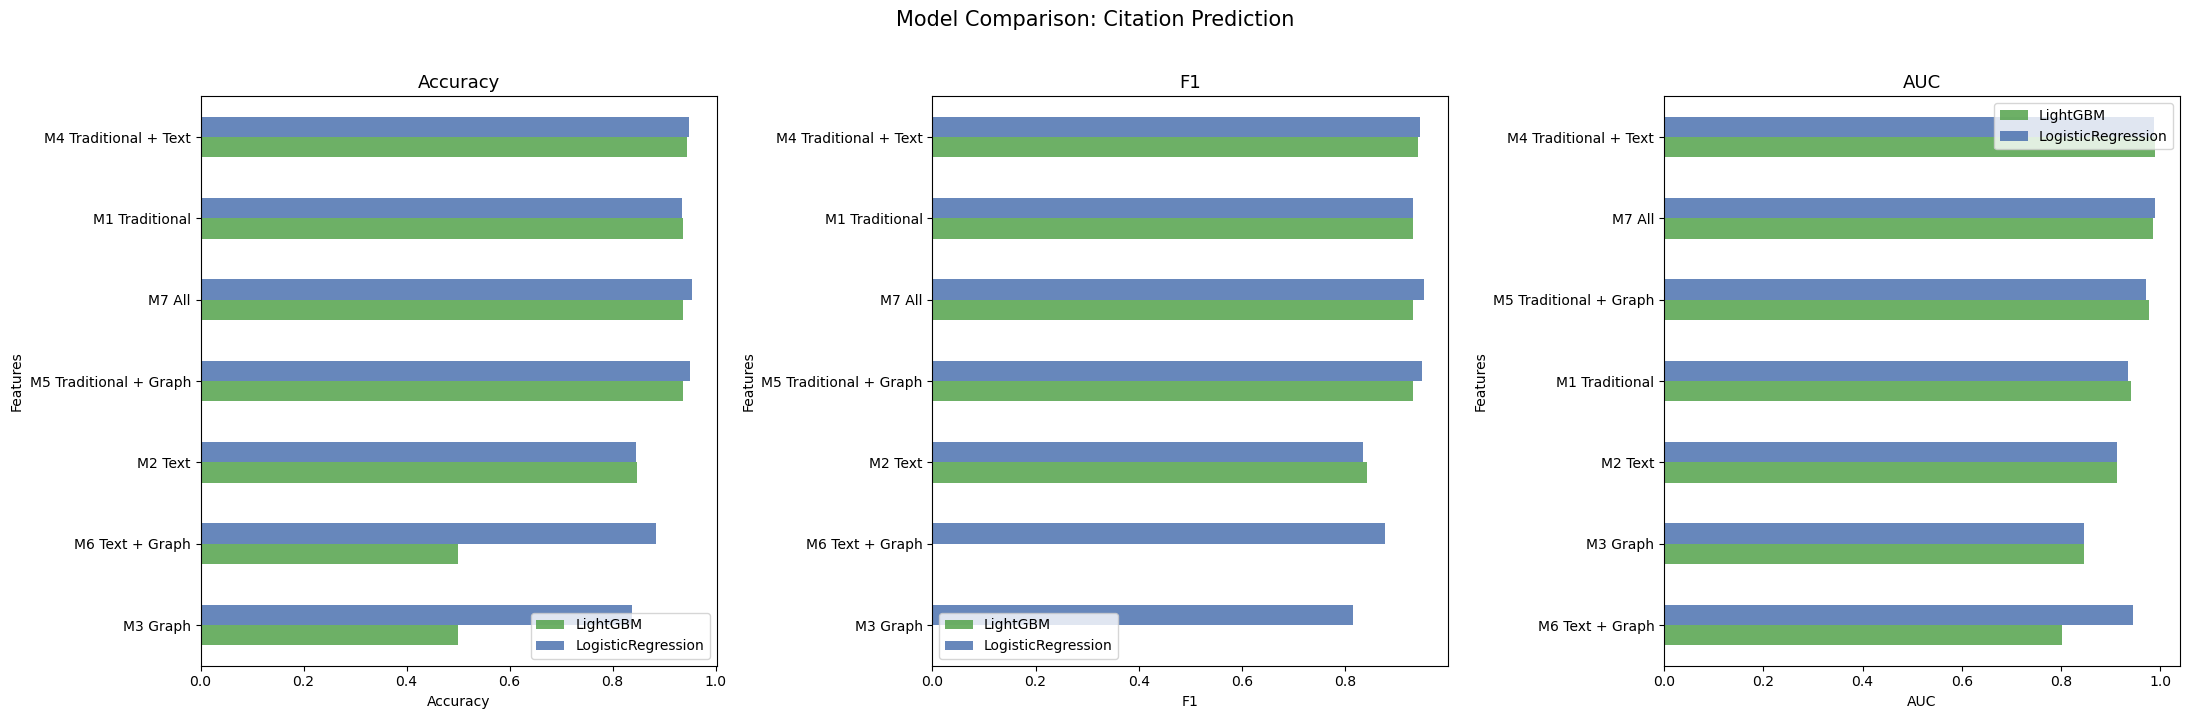

In [21]:
# Results Comparison

#sns.set_theme(style="whitegrid", context="talk")

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
metrics_to_plot = ["Accuracy", "F1", "AUC"]
colors = {"LightGBM": "#54A24B", "LogisticRegression": "#4C72B0"}

for ax, metric in zip(axes, metrics_to_plot):
    pivot = results_df.pivot(index="Features", columns="Model", values=metric)
    pivot = pivot.sort_values(by=pivot.columns[0], ascending=True)
    
    pivot.plot(kind="barh", ax=ax, color=[colors[c] for c in pivot.columns], alpha=0.85)
    ax.set_xlabel(metric)
    ax.set_title(metric, fontsize=13)
    ax.legend(fontsize=10)

plt.suptitle("Model Comparison: Citation Prediction", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()



In [22]:
# Best Model per Feature Combination 
print("── Best model per feature combination (AUC) ──\n")
for combo in FEATURE_COMBINATIONS.keys():
    subset = results_df[results_df["Features"] == combo]
    best = subset.loc[subset["AUC"].idxmax()]
    print(f"  {combo:30s} -> {best['Model']:20s} (AUC={best['AUC']:.4f})")


── Best model per feature combination (AUC) ──

  M1 Traditional                 -> LightGBM             (AUC=0.9413)
  M2 Text                        -> LightGBM             (AUC=0.9130)
  M3 Graph                       -> LogisticRegression   (AUC=0.8455)
  M4 Traditional + Text          -> LightGBM             (AUC=0.9899)
  M5 Traditional + Graph         -> LightGBM             (AUC=0.9776)
  M6 Text + Graph                -> LogisticRegression   (AUC=0.9448)
  M7 All                         -> LogisticRegression   (AUC=0.9896)


Feature Importance — LightGBM 

In [23]:
lgbm_full = trained_models.get("LightGBM")
if lgbm_full is not None:
    m7_features = list(FEATURE_COMBINATIONS["M7 All"])
    importance_df = pd.DataFrame({
        "Feature": m7_features,
        "Importance": lgbm_full.feature_importances_
    }).sort_values("Importance", ascending=True)
    
    def get_group(feat):
        if feat in TRADITIONAL_FEATURES:
            return "Traditional"
        elif feat in TEXT_FEATURES:
            return "Text"
        else:
            return "Graph"
    
    importance_df["Group"] = importance_df["Feature"].apply(get_group)
    group_colors = {"Traditional": "#4C72B0", "Text": "#E45756", "Graph": "#54A24B"}
    
    plt.figure(figsize=(12, 9))
    plt.barh(
        importance_df["Feature"],
        importance_df["Importance"],
        color=[group_colors[g] for g in importance_df["Group"]],
        alpha=0.85
    )
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=g, alpha=0.85) for g, c in group_colors.items()]
    plt.legend(handles=legend_elements, loc="lower right", fontsize=11)
    
    plt.xlabel("Feature Importance (split count)")
    plt.title("Feature Importance — LightGBM Full Model (M7)", fontsize=13)
    plt.tight_layout()
    plt.show()
    
    display(importance_df.sort_values("Importance", ascending=False).round(4))


ValueError: All arrays must be of the same length

In [ ]:
# ROC Curves — Full Model (M7)
m7_features = FEATURE_COMBINATIONS["M7 All"]

plt.figure(figsize=(10, 8))

for model_name, model in trained_models.items():
    if model_name == "LogisticRegression":
        X_eval = X_val_scaled[m7_features]
    else:
        X_eval = X_val[m7_features]
    
    y_proba = np.asarray(model.predict_proba(X_eval))[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc_val = roc_auc_score(y_val, y_proba)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_val:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC=0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Full Model (M7 All Features)")
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ROC Curves — LightGBM all combinations 

In [ ]:
plt.figure(figsize=(10, 8))

for combo_name, feature_list in FEATURE_COMBINATIONS.items():
    model = get_lgbm_model()
    model.fit(X_train[feature_list], y_train)
    y_proba = model.predict_proba(X_val[feature_list])[:, 1]
    
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc_val = roc_auc_score(y_val, y_proba)
    plt.plot(fpr, tpr, label=f"{combo_name} (AUC={auc_val:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random (AUC=0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — LightGBM All Feature Combinations")
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Classification Report — Best Model
best_row = results_df.loc[results_df["AUC"].idxmax()]
best_model_name = best_row["Model"]
best_combo = best_row["Features"]

print(f"Best model: {best_model_name} with {best_combo}")
print(f"AUC: {best_row['AUC']:.4f}\n")

best_features = FEATURE_COMBINATIONS[best_combo]
if "trained_model_lookup" in globals():
    best_model = trained_model_lookup[(best_model_name, best_combo)]
else:
    best_model = joblib.load(MODELS_DIR / f"{best_model_name}_{best_combo}.joblib")

if best_model_name == "LogisticRegression":
    X_eval = X_val_scaled[best_features]
else:
    X_eval = X_val[best_features]

y_pred = best_model.predict(X_eval)
print(classification_report(y_val, y_pred, target_names=["No Citation", "Citation"]))


In [ ]:
# Group Contribution Analysis 

best_type = best_model_name
r = results_df[results_df["Model"] == best_type].set_index("Features")

print(f"── Marginal contribution of each group ({best_type}, AUC) ──\n")

delta_text = r.loc["M4 Traditional + Text", "AUC"] - r.loc["M1 Traditional", "AUC"]
print(f"  Traditional → +Text:  {delta_text:+.4f} AUC")

delta_graph = r.loc["M5 Traditional + Graph", "AUC"] - r.loc["M1 Traditional", "AUC"]
print(f"  Traditional → +Graph: {delta_graph:+.4f} AUC")

delta_text2 = r.loc["M6 Text + Graph", "AUC"] - r.loc["M3 Graph", "AUC"]
print(f"  Graph       → +Text:  {delta_text2:+.4f} AUC")

delta_graph2 = r.loc["M6 Text + Graph", "AUC"] - r.loc["M2 Text", "AUC"]
print(f"  Text        → +Graph: {delta_graph2:+.4f} AUC")

best_duo_name = max(
    ["M4 Traditional + Text", "M5 Traditional + Graph", "M6 Text + Graph"],
    key=lambda m: r.loc[m, "AUC"]
)
delta_all = r.loc["M7 All", "AUC"] - r.loc[best_duo_name, "AUC"]
print(f"\n  Best pair ({best_duo_name}) → +All: {delta_all:+.4f} AUC")

print(f"\n── Summary ──")
best_single = max(["M1 Traditional", "M2 Text", "M3 Graph"], key=lambda m: r.loc[m, "AUC"])
print(f"  Best single group: {best_single} (AUC={r.loc[best_single, 'AUC']:.4f})")
print(f"  Best pair:         {best_duo_name} (AUC={r.loc[best_duo_name, 'AUC']:.4f})")
print(f"  Full model:        M7 All (AUC={r.loc['M7 All', 'AUC']:.4f})")



In [ ]:
# Final Evaluation on Test Set 
print("  FINAL EVALUATION ON TEST SET")

test = pd.read_parquet(DATA_DIR / "test_features_final.parquet")
X_test = test[ALL_FEATURES].astype(np.float32)
y_test = test["label"].values
print(f"\nTest set: {len(test):,} pairs")
print(f"Test labels: {pd.Series(y_test).value_counts().to_dict()}")

del test
gc.collect()

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=ALL_FEATURES
)

m7_features = FEATURE_COMBINATIONS["M7 All"]

for model_name, model in trained_models.items():
    if model_name == "LogisticRegression":
        X_eval = X_test_scaled[m7_features]
    else:
        X_eval = X_test[m7_features]
    
    metrics = evaluate_model(model, X_eval, y_test)
    
    print(f"\n{'─'*50}")
    print(f"  {model_name} (M7 All)")
    print(f"  Accuracy: {metrics['Accuracy']:.4f}")
    print(f"  F1:       {metrics['F1']:.4f}")
    print(f"  AUC:      {metrics['AUC']:.4f}")
    
    y_pred = model.predict(X_eval)
    print(f"\n{classification_report(y_test, y_pred, target_names=['No Citation', 'Citation'])}")
